In [ ]:
import marimo as mo

In [ ]:
title_output = mo.md(f"""
# Assignment 2 - RAG

This notebook contains the code, tables, and write-ups for the FinanceBench RAG assignment.

Runtime policy:
- expensive model, embedding, and evaluation calls are cached per row;
- cache rows are the source of truth for computed results;
- required table deliverables are regenerated from DataFrames;
""")

title_output

# Assignment 2 - RAG

This notebook contains the code, tables, and write-ups for the FinanceBench RAG assignment.

Runtime policy:
- expensive model, embedding, and evaluation calls are cached per row;
- cache rows are the source of truth for computed results;
- required table deliverables are regenerated from DataFrames;

In [ ]:
import ast
import hashlib
import importlib.util as importlib_util
import json
import os
import subprocess
import sys
import time
import urllib.request
from collections.abc import Callable, Iterable
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from datetime import UTC, datetime
from pathlib import Path
from threading import Lock
from typing import Any


In [ ]:
NOTEBOOK_REQUIRED_PACKAGES = [
    "pandas",
    "openpyxl",
    "python-dotenv",
    "litellm",
    "openai",
    "langchain>=1.2.15",
    "langchain-community",
    "langchain-huggingface",
    "langchain-text-splitters",
    "faiss-cpu",
    "sentence-transformers",
    "pypdf",
    "ragas",
    "datasets",
    "tqdm",
    "ipython",
]

PACKAGE_MODULE_OVERRIDES = {
    "python-dotenv": "dotenv",
    "faiss-cpu": "faiss",
}

def package_module_name(package_spec: str) -> str:
    package_name = package_spec
    for separator in ["==", ">=", "<=", "~=", "!=", ">", "<"]:
        package_name = package_name.split(separator, maxsplit=1)[0]
    return PACKAGE_MODULE_OVERRIDES.get(
        package_name, package_name.replace("-", "_")
    )

NOTEBOOK_MISSING_PACKAGES = [
    package_spec
    for package_spec in NOTEBOOK_REQUIRED_PACKAGES
    if importlib_util.find_spec(package_module_name(package_spec)) is None
]

INSTALL_MISSING_PACKAGES = os.getenv("INSTALL_MISSING_PACKAGES", "1") == "1"

if NOTEBOOK_MISSING_PACKAGES:
    NOTEBOOK_INSTALL_COMMAND = (
        "uv add " + " ".join(NOTEBOOK_MISSING_PACKAGES)
    )
    if INSTALL_MISSING_PACKAGES:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", *NOTEBOOK_MISSING_PACKAGES]
        )
        setup_check_output = mo.md(
            "## Setup Check\n\nInstalled missing packages with pip. Restart the notebook kernel before continuing."
        )
    else:
        setup_check_output = mo.md(
            f"""
            ## Setup Check

            Missing required packages:

            `{NOTEBOOK_INSTALL_COMMAND}`

            To install from inside the notebook instead, restart with `INSTALL_MISSING_PACKAGES=1`.
            """
        )
        mo.stop(True, setup_check_output)
else:
    NOTEBOOK_INSTALL_COMMAND = ""
    setup_check_output = mo.md(
        "## Setup Check\n\nAll required notebook packages are importable."
    )

setup_check_output

## Setup Check

Installed missing packages with pip. Restart the notebook kernel before continuing.

In [ ]:
import pandas as pd
from dotenv import load_dotenv
from tqdm.auto import tqdm

In [ ]:
if "__file__" in globals():
    NOTEBOOK_PATH = Path(__file__).resolve()
    NOTEBOOK_DIR = NOTEBOOK_PATH.parent
else:
    NOTEBOOK_DIR = Path.cwd().resolve() / "w2-ai-product"
    NOTEBOOK_PATH = NOTEBOOK_DIR / "ai-product-2.py"

REPO_ROOT = NOTEBOOK_DIR.parent
ASSIGNMENT_SOURCE_DIR = REPO_ROOT / "ai-product-2"
ASSIGNMENT2_DATA_DIR = NOTEBOOK_DIR / "data" / "assignment2"
ASSIGNMENT2_OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "assignment2"
ASSIGNMENT2_CACHE_DIR = ASSIGNMENT2_OUTPUTS_DIR / "cache"
ASSIGNMENT2_VECTORSTORE_DIR = ASSIGNMENT2_OUTPUTS_DIR / "vectorstores"
FINANCEBENCH_PDF_DIR = ASSIGNMENT2_DATA_DIR / "financebench_pdfs"

for notebook_directory in [
    ASSIGNMENT2_DATA_DIR,
    ASSIGNMENT2_OUTPUTS_DIR,
    ASSIGNMENT2_CACHE_DIR,
    ASSIGNMENT2_VECTORSTORE_DIR,
    FINANCEBENCH_PDF_DIR,
]:
    notebook_directory.mkdir(parents=True, exist_ok=True)

load_dotenv(NOTEBOOK_DIR / ".env")

# ── Runtime flags ────────────────────────────────────────────────────
# Set to True to enable; loaded from .env when available.
FORCE_RERUN = os.getenv("FORCE_RERUN", "0") == "1"
RETRY_ERRORS = os.getenv("RETRY_ERRORS", "1") == "1"
RUN_MODEL_CALLS = os.getenv("RUN_MODEL_CALLS", "1") == "1"
RUN_EXPENSIVE_EVALS = os.getenv("RUN_EXPENSIVE_EVALS", "1") == "1"
RUN_FAITHFULNESS = os.getenv("RUN_FAITHFULNESS", "1") == "1"
ALLOW_DOWNLOADS = os.getenv("ALLOW_DOWNLOADS", "1") == "1"
OUTPUT_FORMAT = os.getenv("OUTPUT_FORMAT", "both").lower()
if OUTPUT_FORMAT not in {"xlsx", "csv", "both"}:
    raise ValueError("OUTPUT_FORMAT must be one of: xlsx, csv, both")

# ── API keys & endpoints ─────────────────────────────────────────────
# Replace the default strings below if running without a .env file.
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "").strip()
NEBIUS_API_KEY = os.getenv("NEBIUS_API_KEY", default="insert-your-nebius-api-key-here").strip()
NEBIUS_BASE_URL = os.getenv("NEBIUS_BASE_URL", default="https://api.tokenfactory.nebius.com/v1/").strip()

# ── Model selection ──────────────────────────────────────────────────
GENERATION_MODEL = os.getenv("ASSIGNMENT2_GENERATION_MODEL", default="meta-llama/Llama-3.3-70B-Instruct").strip()
JUDGE_MODEL = os.getenv("ASSIGNMENT2_JUDGE_MODEL", default="deepseek-ai/DeepSeek-V3.2").strip()
EMBEDDING_MODEL = os.getenv("ASSIGNMENT2_EMBEDDING_MODEL", default="BAAI/bge-small-en-v1.5").strip()
RERANKER_MODEL = os.getenv("ASSIGNMENT2_RERANKER_MODEL", default="BAAI/bge-reranker-base").strip()

# ── Evaluation parameters ────────────────────────────────────────────
FAITHFULNESS_LIMIT = int(os.getenv("FAITHFULNESS_LIMIT", "20"))
DEFAULT_RETRIEVAL_K = int(os.getenv("DEFAULT_RETRIEVAL_K", "4"))
PAGE_HIT_K_VALUES = [1, 3, 5]

FINANCEBENCH_LOCAL_JSON = ASSIGNMENT2_DATA_DIR / "financebench.json"
FINANCEBENCH_LOCAL_CSV = ASSIGNMENT2_DATA_DIR / "financebench.csv"
FINANCEBENCH_LOCAL_PARQUET = ASSIGNMENT2_DATA_DIR / "financebench.parquet"

ASSIGNMENT2_NAIVE_BASE = ASSIGNMENT2_OUTPUTS_DIR / "assignment2_naive_generation"
ASSIGNMENT2_COMPARE_BASE = ASSIGNMENT2_OUTPUTS_DIR / "assignment2_run_and_compare"
ASSIGNMENT2_EVAL_BASE = ASSIGNMENT2_OUTPUTS_DIR / "assignment2_evaluation"
ASSIGNMENT2_IMPROVEMENT_BASE = (
    ASSIGNMENT2_OUTPUTS_DIR / "assignment2_improvement_cycles"
)

TASK1_CACHE_PATH = ASSIGNMENT2_CACHE_DIR / "task1_naive_generation.jsonl"
TASK4_CACHE_PATH = ASSIGNMENT2_CACHE_DIR / "task4_rag_answers.jsonl"
TASK6_CORRECTNESS_CACHE_PATH = ASSIGNMENT2_CACHE_DIR / "task6_correctness.jsonl"
TASK6_FAITHFULNESS_CACHE_PATH = ASSIGNMENT2_CACHE_DIR / "task6_faithfulness.jsonl"
TASK7_EXPERIMENT_CACHE_PATH = ASSIGNMENT2_CACHE_DIR / "task7_experiments.jsonl"

In [ ]:
runtime_flags_output = mo.md(
    f"""
    ## Runtime Flags

    - `RUN_MODEL_CALLS`: `{RUN_MODEL_CALLS}`
    - `RUN_EXPENSIVE_EVALS`: `{RUN_EXPENSIVE_EVALS}`
    - `RUN_FAITHFULNESS`: `{RUN_FAITHFULNESS}`
    - `FORCE_RERUN`: `{FORCE_RERUN}`
    - `RETRY_ERRORS`: `{RETRY_ERRORS}`
    - `ALLOW_DOWNLOADS`: `{ALLOW_DOWNLOADS}`
    - `GENERATION_MODEL`: `{GENERATION_MODEL}`
    - `JUDGE_MODEL`: `{JUDGE_MODEL}`
    - `EMBEDDING_MODEL`: `{EMBEDDING_MODEL}`
    - `DEFAULT_RETRIEVAL_K`: `{DEFAULT_RETRIEVAL_K}`
    - `FAITHFULNESS_LIMIT`: `{FAITHFULNESS_LIMIT}`
    - `NEBIUS_BASE_URL`: `{NEBIUS_BASE_URL}`
    - `NEBIUS_API_KEY` present: `{bool(NEBIUS_API_KEY)}`
    - `OUTPUT_FORMAT`: `{OUTPUT_FORMAT}`
    """
)
runtime_flags_output

## Runtime Flags

- `RUN_MODEL_CALLS`: `True`
- `RUN_EXPENSIVE_EVALS`: `True`
- `RUN_FAITHFULNESS`: `True`
- `FORCE_RERUN`: `False`
- `RETRY_ERRORS`: `True`
- `ALLOW_DOWNLOADS`: `True`
- `GENERATION_MODEL`: `meta-llama/Llama-3.3-70B-Instruct`
- `JUDGE_MODEL`: `deepseek-ai/DeepSeek-V3.2`
- `EMBEDDING_MODEL`: `BAAI/bge-small-en-v1.5`
- `DEFAULT_RETRIEVAL_K`: `4`
- `FAITHFULNESS_LIMIT`: `20`
- `NEBIUS_BASE_URL`: `https://api.tokenfactory.nebius.com/v1/`
- `NEBIUS_API_KEY` present: `True`
- `OUTPUT_FORMAT`: `both`

In [ ]:
def utc_now_iso() -> str:
    return datetime.now(UTC).isoformat()


def stable_json(value: Any) -> str:
    return json.dumps(value, sort_keys=True, ensure_ascii=True, default=str)


def stable_hash(value: Any) -> str:
    return hashlib.sha256(stable_json(value).encode("utf-8")).hexdigest()


def text_hash(value: str) -> str:
    return hashlib.sha256(value.encode("utf-8")).hexdigest()


def package_rows(rows: Iterable[dict[str, Any]]) -> list[dict[str, Any]]:
    return [dict(row) for row in rows]


def round_metric_columns(
    df: pd.DataFrame,
    columns: Iterable[str],
    digits: int = 3,
) -> pd.DataFrame:
    rounded_df = df.copy()
    for _metric_column in columns:
        if _metric_column in rounded_df.columns:
            rounded_df[_metric_column] = pd.to_numeric(
                rounded_df[_metric_column],
                errors="coerce",
            ).round(digits)
    return rounded_df


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    if not path.exists():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            stripped = line.strip()
            if stripped:
                try:
                    rows.append(json.loads(stripped))
                except json.JSONDecodeError as exc:
                    print(
                        f"[cache] Skipping malformed JSONL row "
                        f"{path}:{line_number}: {exc}"
                    )
    return rows


def write_jsonl(path: Path, rows: Iterable[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_name(f".{path.name}.{time.time_ns()}.tmp")
    with tmp_path.open("w", encoding="utf-8") as file:
        for row in rows:
            file.write(stable_json(row) + "\n")
    tmp_path.replace(path)


def load_cache_df(path: Path) -> pd.DataFrame:
    rows = read_jsonl(path)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)


def cache_lookup(
    cache_df: pd.DataFrame,
    *,
    task: str,
    financebench_id: str,
    input_hash: str,
    config_hash: str,
) -> dict[str, Any] | None:
    if cache_df.empty:
        return None
    required_columns = {
        "task",
        "financebench_id",
        "input_hash",
        "config_hash",
        "status",
    }
    if not required_columns.issubset(cache_df.columns):
        return None
    matches = cache_df[
        (cache_df["task"] == task)
        & (cache_df["financebench_id"] == financebench_id)
        & (cache_df["input_hash"] == input_hash)
        & (cache_df["config_hash"] == config_hash)
    ]
    if matches.empty:
        return None
    return matches.iloc[-1].to_dict()


def upsert_cache_row(path: Path, row: dict[str, Any]) -> None:
    rows = read_jsonl(path)
    key_fields = ["task", "financebench_id", "input_hash", "config_hash"]
    filtered_rows = [
        existing
        for existing in rows
        if any(existing.get(field) != row.get(field) for field in key_fields)
    ]
    filtered_rows.append(row)
    write_jsonl(path, filtered_rows)


def make_status_row(
    *,
    task: str,
    financebench_id: str,
    input_payload: dict[str, Any],
    config_payload: dict[str, Any],
    status: str,
    result_payload: dict[str, Any] | None = None,
    attempts: int = 0,
    error_message: str = "",
) -> dict[str, Any]:
    return {
        "task": task,
        "financebench_id": financebench_id,
        "status": status,
        "input_hash": stable_hash(input_payload),
        "config_hash": stable_hash(config_payload),
        "attempts": attempts,
        "error_message": error_message,
        "completed_at": utc_now_iso() if status == "done" else "",
        "created_at": utc_now_iso(),
        **(result_payload or {}),
    }


def run_cached_rows(
    *,
    task: str,
    rows: list[dict[str, Any]],
    cache_path: Path,
    config_payload: dict[str, Any],
    input_payload_fn: Callable[[dict[str, Any]], dict[str, Any]],
    run_one_fn: Callable[[dict[str, Any]], dict[str, Any]],
    force_rerun: bool,
    retry_errors: bool,
    allow_run: bool,
    max_workers: int = 4,
) -> pd.DataFrame:
    cache_df = load_cache_df(cache_path)
    config_hash = stable_hash(config_payload)
    cache_lock = Lock()

    # First pass: separate cached hits from rows that need execution
    output_rows: dict[int, dict[str, Any]] = {}
    to_run: list[tuple[int, dict[str, Any], dict[str, Any], dict | None]] = []

    for idx, source_row in enumerate(rows):
        financebench_id = str(source_row["financebench_id"])
        input_payload = input_payload_fn(source_row)
        input_hash = stable_hash(input_payload)
        cached = cache_lookup(
            cache_df,
            task=task,
            financebench_id=financebench_id,
            input_hash=input_hash,
            config_hash=config_hash,
        )
        if (
            cached
            and cached.get("status") == "done"
            and not force_rerun
        ):
            output_rows[idx] = cached
            continue
        if (
            cached
            and cached.get("status") == "error"
            and not force_rerun
            and not retry_errors
        ):
            output_rows[idx] = cached
            continue
        if not allow_run:
            pending_row = make_status_row(
                task=task,
                financebench_id=financebench_id,
                input_payload=input_payload,
                config_payload=config_payload,
                status="pending",
                result_payload={"source_row": stable_json(source_row)},
            )
            output_rows[idx] = pending_row
            continue
        to_run.append((idx, source_row, input_payload, cached))

    # Second pass: run pending rows concurrently
    def _execute_one(item: tuple[int, dict, dict, dict | None]) -> tuple[int, dict[str, Any]]:
        idx, source_row, input_payload, cached = item
        financebench_id = str(source_row["financebench_id"])
        try:
            result_payload = run_one_fn(source_row)
            row = make_status_row(
                task=task,
                financebench_id=financebench_id,
                input_payload=input_payload,
                config_payload=config_payload,
                status="done",
                result_payload=result_payload,
                attempts=int((cached or {}).get("attempts", 0)) + 1,
            )
        except Exception as exc:
            row = make_status_row(
                task=task,
                financebench_id=financebench_id,
                input_payload=input_payload,
                config_payload=config_payload,
                status="error",
                result_payload={"source_row": stable_json(source_row)},
                attempts=int((cached or {}).get("attempts", 0)) + 1,
                error_message=repr(exc),
            )
        with cache_lock:
            upsert_cache_row(cache_path, row)
        return idx, row

    if to_run:
        progress = tqdm(
            total=len(rows),
            desc=f"[{task}]",
            unit="row",
            file=sys.stdout,
            mininterval=0.5,
        )
        progress.update(len(output_rows))  # count cache hits
        progress.refresh()
        with ThreadPoolExecutor(max_workers=max_workers) as pool:
            futures = {pool.submit(_execute_one, item): item for item in to_run}
            for future in as_completed(futures):
                idx, row = future.result()
                output_rows[idx] = row
                progress.update(1)
        progress.close()
    else:
        # All from cache, still show progress
        for _ in tqdm(
            rows,
            desc=f"[{task}] (cached)",
            unit="row",
            file=sys.stdout,
            mininterval=0.5,
        ):
            pass

    return pd.DataFrame([output_rows[i] for i in sorted(output_rows)])


def export_table(
    df: pd.DataFrame,
    base_path: Path,
    required_columns: list[str],
    output_format: str,
) -> list[Path]:
    export_df = df.copy()
    for column in required_columns:
        if column not in export_df.columns:
            export_df[column] = ""
    export_df = export_df[required_columns]
    base_path.parent.mkdir(parents=True, exist_ok=True)
    written_paths = []
    if output_format in {"xlsx", "both"}:
        xlsx_path = base_path.with_suffix(".xlsx")
        export_df.to_excel(xlsx_path, index=False)
        written_paths.append(xlsx_path)
    if output_format in {"csv", "both"}:
        csv_path = base_path.with_suffix(".csv")
        export_df.to_csv(csv_path, index=False)
        written_paths.append(csv_path)
    return written_paths


def dataframe_to_markdown_table(df: pd.DataFrame, max_rows: int = 20) -> str:
    if df.empty:
        return "_No rows available._"
    return df.head(max_rows).to_markdown(index=False)


def display_table(df: pd.DataFrame, mo_module, max_rows: int = 20):
    if df.empty:
        return mo_module.md("_No rows available._")
    return mo_module.ui.table(df.head(max_rows), pagination=True)


def parse_evidence_items(evidence: Any) -> list[dict[str, Any]]:
    if isinstance(evidence, list):
        return [
            item if isinstance(item, dict) else {"value": item}
            for item in evidence
        ]
    if isinstance(evidence, dict):
        return [evidence]
    if pd.isna(evidence):
        return []
    if isinstance(evidence, str):
        stripped = evidence.strip()
        if not stripped:
            return []
        for parser in (json.loads, ast.literal_eval):
            try:
                parsed = parser(stripped)
                return parse_evidence_items(parsed)
            except Exception:
                continue
        return [{"evidence_text": stripped}]
    return []


def evidence_page_numbers(evidence: Any) -> list[int]:
    page_numbers = []
    for item in parse_evidence_items(evidence):
        for key in ["evidence_page_num", "page_number", "page", "page_num"]:
            if key in item and item[key] not in (None, ""):
                try:
                    page_numbers.append(int(item[key]))
                except (TypeError, ValueError):
                    pass
    return sorted(set(page_numbers))


def evidence_texts(evidence: Any) -> list[str]:
    texts = []
    for item in parse_evidence_items(evidence):
        text = item.get("evidence_text") or item.get("text") or item.get("value")
        if text:
            texts.append(str(text))
    return texts


def source_fingerprint(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {"path": str(path), "exists": False}
    stat = path.stat()
    return {
        "path": str(path),
        "exists": True,
        "size": stat.st_size,
        "mtime_ns": stat.st_mtime_ns,
    }


def write_manifest(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(stable_json(payload), encoding="utf-8")


def read_manifest(path: Path) -> dict[str, Any] | None:
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def manifest_matches(path: Path, payload: dict[str, Any]) -> bool:
    return read_manifest(path) == payload


def download_file(url: str, destination: Path) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url, timeout=60) as response:
        destination.write_bytes(response.read())
    return destination


def require_api_key(api_key: str) -> None:
    if not api_key:
        raise RuntimeError("NEBIUS_API_KEY is required for this call.")


def call_chat_model(
    *,
    model: str,
    messages: list[dict[str, str]],
    api_key: str,
    base_url: str,
    temperature: float = 0.0,
    max_tokens: int = 512,
    timeout: float = 120.0,
) -> str:
    require_api_key(api_key)
    import litellm

    response = litellm.completion(
        model=f"openai/{model}",
        messages=messages,
        api_key=api_key,
        api_base=base_url,
        temperature=temperature,
        max_tokens=max_tokens,
        timeout=timeout,
    )
    return response.choices[0].message.content or ""


def retry_call(
    fn: Callable[[], Any],
    *,
    attempts: int = 3,
    sleep_seconds: float = 2.0,
) -> Any:
    last_exc = None
    for attempt_index in range(attempts):
        try:
            return fn()
        except Exception as exc:
            last_exc = exc
            if attempt_index + 1 < attempts:
                time.sleep(sleep_seconds * (attempt_index + 1))
    raise last_exc


@dataclass(frozen=True)
class RagExperimentConfig:
    experiment: str
    change: str
    vectorstore_name: str
    chunk_size: int
    chunk_overlap: int
    generator_model: str
    generation_prompt_version: str
    k_for_generation: int
    use_reranker: bool = False
    rerank_fetch_k: int = 20
    hypothesis: str = ""

    def to_payload(self) -> dict[str, Any]:
        return {
            "experiment": self.experiment,
            "change": self.change,
            "vectorstore_name": self.vectorstore_name,
            "chunk_size": self.chunk_size,
            "chunk_overlap": self.chunk_overlap,
            "generator_model": self.generator_model,
            "generation_prompt_version": self.generation_prompt_version,
            "k_for_generation": self.k_for_generation,
            "use_reranker": self.use_reranker,
            "rerank_fetch_k": self.rerank_fetch_k,
            "hypothesis": self.hypothesis,
        }


In [ ]:
dataset_prep_output = mo.md(f"""
## Dataset Preparation

FinanceBench is filtered to remove `metrics-generated` questions. The remaining rows are sorted by `financebench_id`.
""")
dataset_prep_output

## Dataset Preparation

FinanceBench is filtered to remove `metrics-generated` questions. The remaining rows are sorted by `financebench_id`.

In [ ]:
def load_financebench_raw() -> pd.DataFrame:
    if FINANCEBENCH_LOCAL_JSON.exists():
        return pd.read_json(FINANCEBENCH_LOCAL_JSON)
    if FINANCEBENCH_LOCAL_CSV.exists():
        return pd.read_csv(FINANCEBENCH_LOCAL_CSV)
    if FINANCEBENCH_LOCAL_PARQUET.exists():
        return pd.read_parquet(FINANCEBENCH_LOCAL_PARQUET)
    try:
        from datasets import load_dataset
    except ImportError as exc:
        raise RuntimeError(
            "Install `datasets` or place financebench.csv/json/parquet under "
            f"{ASSIGNMENT2_DATA_DIR}."
        ) from exc
    dataset = load_dataset("PatronusAI/financebench", split="train")
    raw_df = dataset.to_pandas()
    FINANCEBENCH_LOCAL_JSON.parent.mkdir(parents=True, exist_ok=True)
    raw_df.to_json(FINANCEBENCH_LOCAL_JSON, orient="records", indent=2)
    return raw_df


def load_filtered_financebench() -> pd.DataFrame:
    raw_df = load_financebench_raw()
    filtered_df = raw_df[raw_df["question_type"] != "metrics-generated"].copy()
    filtered_df = filtered_df.sort_values("financebench_id").reset_index(drop=True)
    return filtered_df


def financebench_pdf_path(doc_name: str) -> str:
    return str(FINANCEBENCH_PDF_DIR / f"{doc_name}.pdf")


def maybe_download_financebench_pdf(doc_name: str) -> str:
    destination = FINANCEBENCH_PDF_DIR / f"{doc_name}.pdf"
    if destination.exists():
        return str(destination)
    if not ALLOW_DOWNLOADS:
        return str(destination)
    from urllib.parse import quote
    import urllib.request

    encoded_name = quote(f"{doc_name}.pdf")
    url = (
        "https://raw.githubusercontent.com/patronus-ai/financebench/main/pdfs/"
        + encoded_name
    )
    with urllib.request.urlopen(url, timeout=60) as response:
        destination.write_bytes(response.read())
    return str(destination)


try:
    financebench_df = load_filtered_financebench()
    financebench_load_error = ""
except Exception as financebench_exc:
    financebench_df = pd.DataFrame()
    financebench_load_error = repr(financebench_exc)

if not financebench_df.empty:
    financebench_df["pdf_path"] = [
        maybe_download_financebench_pdf(doc_name)
        for doc_name in tqdm(
            financebench_df["doc_name"],
            desc="Resolving PDFs",
            unit="file",
        )
    ]

financebench_summary_df = (
    financebench_df.groupby("question_type", dropna=False)
    .size()
    .reset_index(name="rows")
    if not financebench_df.empty
    else pd.DataFrame(columns=["question_type", "rows"])
)

Resolving PDFs: 100%|██████████| 100/100 [00:00<00:00, 105729.87file/s]


In [ ]:
if financebench_load_error:
    dataset_status_output = mo.md(f"Dataset load status: `{financebench_load_error}`")
else:
    dataset_status_output = display_table(financebench_summary_df, mo)
dataset_status_output

,_marimo_row_id,question_type,rows
0,0,domain-relevant,50
1,1,novel-generated,50


In [ ]:
dataset_prep_qa_output = mo.md(f"""
Q: How many rows remain and were document files already local or downloaded?

A: {len(financebench_df)} rows; files were resolved locally or downloaded.
""")
dataset_prep_qa_output

Q: How many rows remain and were document files already local or downloaded?

A: 100 rows; files were resolved locally or downloaded.

In [ ]:
task1_prompt_output = mo.md(f"""
## Task 1 - Naive Generation

Run the first 5 `domain-relevant` and first 5 `novel-generated` questions through the generation model without retrieval.
""")
task1_prompt_output

## Task 1 - Naive Generation

Run the first 5 `domain-relevant` and first 5 `novel-generated` questions through the generation model without retrieval.

In [ ]:
# TASK1_SYSTEM_PROMPT = """You answer finance questions directly. If the question requires document-specific context that is not provided, say that the filing context is needed instead of guessing."""
TASK1_SYSTEM_PROMPT = """"""

def select_task1_questions(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    selected_parts = []
    for question_type in ["domain-relevant", "novel-generated"]:
        selected_parts.append(
            df[df["question_type"] == question_type]
            .sort_values("financebench_id")
            .head(5)
        )
    return pd.concat(selected_parts, ignore_index=True)


task1_questions_df = select_task1_questions(financebench_df)


def run_task1_one(row: dict) -> dict:
    answer = retry_call(
        lambda: call_chat_model(
            model=GENERATION_MODEL,
            api_key=NEBIUS_API_KEY,
            base_url=NEBIUS_BASE_URL,
            messages=[
                {"role": "system", "content": TASK1_SYSTEM_PROMPT},
                {"role": "user", "content": str(row["question"])},
            ],
            temperature=0.0,
            max_tokens=512,
        )
    )
    return {
        "question_type": row.get("question_type", ""),
        "question": row.get("question", ""),
        "naive_answer": answer,
        "ground_truth": row.get("answer", ""),
        "verdict": "",
        "model": GENERATION_MODEL,
    }


task1_cache_df = run_cached_rows(
    task="task1_naive_generation",
    rows=package_rows(task1_questions_df.to_dict("records")),
    cache_path=TASK1_CACHE_PATH,
    config_payload={
        "model": GENERATION_MODEL,
        "prompt": TASK1_SYSTEM_PROMPT,
        "temperature": 0.0,
    },
    input_payload_fn=lambda row: {
        "financebench_id": row["financebench_id"],
        "question": row["question"],
    },
    run_one_fn=run_task1_one,
    force_rerun=FORCE_RERUN,
    retry_errors=RETRY_ERRORS,
    allow_run=RUN_MODEL_CALLS,
)

if task1_cache_df.empty:
    task1_naive_generation_df = pd.DataFrame(
        columns=[
            "financebench_id",
            "question_type",
            "question",
            "naive_answer",
            "ground_truth",
            "verdict",
        ]
    )
else:
    task1_naive_generation_df = task1_cache_df.copy()
    if "ground_truth" not in task1_naive_generation_df.columns:
        task1_naive_generation_df = task1_naive_generation_df.merge(
            task1_questions_df[
                ["financebench_id", "question_type", "question", "answer"]
            ].rename(columns={"answer": "ground_truth"}),
            on="financebench_id",
            how="left",
        )

task1_export_paths = export_table(
    task1_naive_generation_df,
    ASSIGNMENT2_NAIVE_BASE,
    [
        "financebench_id",
        "question_type",
        "question",
        "naive_answer",
        "ground_truth",
        "verdict",
    ],
    OUTPUT_FORMAT,
)

[task1_naive_generation] (cached): 100%|██████████| 10/10 [00:00<00:00, 384798.53row/s]


In [ ]:
task1_table_output = display_table(task1_naive_generation_df, mo)
task1_table_output

,_marimo_row_id,attempts,completed_at,config_hash,created_at,error_message,financebench_id,input_hash,source_row,status,task,ground_truth,model,naive_answer,question,question_type,verdict
0,0,1,2026-04-27T10:47:23.318288+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:23.318297+00:00,,financebench_id_00005,be7d8e7f97a19eb960e90fd9a5868da6a5ca56529f0934...,NaN,done,task1_naive_generation,Yes. Corning had a positive working capital am...,meta-llama/Llama-3.3-70B-Instruct,To determine if Corning has positive working c...,Does Corning have positive working capital bas...,domain-relevant,
1,1,1,2026-04-27T10:47:23.397173+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:23.397184+00:00,,financebench_id_00070,903dcf63d3430cce4304fbed93d62df04799f7dce21150...,NaN,done,task1_naive_generation,"No, American Water Works had negative working ...",meta-llama/Llama-3.3-70B-Instruct,To determine if American Water Works has posit...,Does American Water Works have positive workin...,domain-relevant,
2,2,1,2026-04-27T10:47:22.008665+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:22.008677+00:00,,financebench_id_00080,1bfd397004ffffeb85a6030db3017814a0b8ddfef12101...,NaN,done,task1_naive_generation,Yes. Paypal has a positive working capital of ...,meta-llama/Llama-3.3-70B-Instruct,To determine if PayPal has positive working ca...,Does Paypal have positive working capital base...,domain-relevant,
3,3,1,2026-04-27T10:47:21.412793+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:21.412810+00:00,,financebench_id_00206,6f9b72f0f32bd8dd37fa4d227679ace6ae1565c1380abd...,NaN,done,task1_naive_generation,"Since JPM is a financial institution, gross ma...",meta-llama/Llama-3.3-70B-Instruct,JPMorgan Chase (JPM) is a multinational bank a...,Are JPM's gross margins historically consisten...,domain-relevant,
4,4,1,2026-04-27T10:47:32.434769+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:32.434783+00:00,,financebench_id_00215,ce4dc237ec6fcd02fe1e6f1cd2b3eb8f0b511aada31d7f...,NaN,done,task1_naive_generation,Yes. Verizon's capital intensity ratio was app...,meta-llama/Llama-3.3-70B-Instruct,To determine if Verizon is a capital-intensive...,Is Verizon a capital intensive business based ...,domain-relevant,
5,5,1,2026-04-27T10:47:22.705877+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:22.705891+00:00,,financebench_id_00283,8eed233391b38f32ecbeb6c39f648f3f4a9d8780400555...,NaN,done,task1_naive_generation,77.78,meta-llama/Llama-3.3-70B-Instruct,Pfizer expects to pay approximately $12 billio...,How much does Pfizer expect to pay to spin off...,novel-generated,
6,6,1,2026-04-27T10:47:25.648515+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:25.648529+00:00,,financebench_id_00288,11b638dec8bd3d4ec227bc8ea5394100273344b6c1e2be...,NaN,done,task1_naive_generation,"Yes, there was a decline of ~42% between FY202...",meta-llama/Llama-3.3-70B-Instruct,I don't have access to real-time financial dat...,Was there any drop in Cash & Cash equivalents ...,novel-generated,
7,7,1,2026-04-27T10:47:24.751526+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:24.751534+00:00,,financebench_id_00299,d3912ef262a3d260ecbd9dc96663a0ba5e7c5de579f14e...,NaN,done,task1_naive_generation,Corporate. Its net revenue was -$473 million.,meta-llama/Llama-3.3-70B-Instruct,According to JPMorgan Chase's Q1 2021 earnings...,Which of JPM's business segments had the lowes...,novel-generated,
8,8,1,2026-04-27T10:47:26.290150+00:00,236d60f632697b2f676b8a79049289aa7ce51b1c5061d1...,2026-04-27T10:47:26.290166+00:00,,financebench_id_00302,88f019890f87a3d27b529302137e07e114525d9664ad73...,NaN,done,task1_naive_generation,"Yes, change in PPNE was positive year over year",meta-llama/Llama-3.3-70B-Instruct,"Pfizer did grow its Pharmaceutical Pipeline, P...",Did Pfizer grow its PPNE between FY20 and FY21?,novel-generated,
9,

In [ ]:
task1_qa_output = mo.md(f"""
Q: Where did the model refuse or ask for more information, and why?

A: For some reason the model only refused to answer questions on global markets and data.
Both requests did NOT name the company, so no 'start data' to confabulate.

With another prompt like 'You answer finance questions directly. If the question requires document-specific context that is not provided, say that the filing context is needed instead of guessing.' it refused almost all the questions → which is great and expected with such a prompt.

Q: Where did the model answer confidently, and how did it compare with the ground truth?

A: All the questions on particular companies and their filing data - wonderfully hallucinated!

Q: What patterns appear by `question_type`?

A: Domain-relevant questions seem to have more of a 'To determine' + hallucinations. Novel-generated questions are more varied in answer patterns.
""")
task1_qa_output

Q: Where did the model refuse or ask for more information, and why?

A: For some reason the model only refused to answer questions on global markets and data.
Both requests did NOT name the company, so no 'start data' to confabulate.

With another prompt like 'You answer finance questions directly. If the question requires document-specific context that is not provided, say that the filing context is needed instead of guessing.' it refused almost all the questions → which is great and expected with such a prompt.

Q: Where did the model answer confidently, and how did it compare with the ground truth?

A: All the questions on particular companies and their filing data - wonderfully hallucinated!

Q: What patterns appear by `question_type`?

A: Domain-relevant questions seem to have more of a 'To determine' + hallucinations. Novel-generated questions are more varied in answer patterns.

In [ ]:
task2_output = mo.md(f"""
## Task 2 - RAG Reminder

**Indexing**

Q: Explain how documents are loaded, split, embedded, and saved. Include where indexing can fail and whether it is offline or per query.

A: Documents are loaded from local PDF files using LangChain's `PyPDFLoader`, which extracts one `Document` object per page. Each page is enriched with metadata (`doc_name`, `company`, `doc_period`, `page_number`). Pages are then split into chunks using `RecursiveCharacterTextSplitter` with `chunk_size=1000` and `chunk_overlap=150`. Chunks are embedded using `BAAI/bge-small-en-v1.5` via `HuggingFaceEmbeddings` and stored in a FAISS vector index saved to disk alongside a JSON manifest that records document fingerprints and embedding config. Indexing is **offline** — it runs once and is reused across queries. It can fail if a PDF file is missing (`FileNotFoundError`), if the embedding model fails to load (network or disk issue), or if FAISS serialization fails (disk space).

**Retrieval**

Q: Explain how the user query is embedded and matched to stored chunks. Include concrete retrieval failure examples and whether it happens per query.

A: The user query is embedded with the same `BAAI/bge-small-en-v1.5` model used at index time. FAISS performs approximate nearest-neighbor search over the stored vectors and returns the top-k chunks (default k=4). This happens **per query**. Retrieval can fail if the vectorstore was not built or loaded (returns empty results), if the query is semantically distant from all indexed content (returns irrelevant chunks), or if the relevant information spans multiple pages and the chunk boundaries split it (partial or misleading context). A concrete example: a question about a specific financial metric may retrieve chunks from the right company but wrong fiscal year if the embedding similarity is close.

**Generation**

Q: Explain how retrieved chunks are put into the prompt. Include where generation can fail and whether it happens per query.

A: Retrieved chunks are formatted into a numbered list (e.g., `[Chunk 1]`) with their `doc_name`, `page_number`, and full text content, separated by `---` dividers. This formatted context is appended to the user's question in the user message, while a system prompt instructs the model to answer only from the provided context and cite sources. The full prompt is sent to `meta-llama/Llama-3.3-70B-Instruct` via the Nebius API through LiteLLM. This happens **per query**. Generation can fail if the API key is missing or invalid (`RuntimeError`), if the API times out (120s default), if the model is overloaded (rate limiting / 5xx errors — mitigated by `retry_call` with 3 attempts), or if the retrieved context is irrelevant causing the model to hallucinate or refuse.
""")
task2_output

## Task 2 - RAG Reminder

**Indexing**

Q: Explain how documents are loaded, split, embedded, and saved. Include where indexing can fail and whether it is offline or per query.

A: Documents are loaded from local PDF files using LangChain's `PyPDFLoader`, which extracts one `Document` object per page. Each page is enriched with metadata (`doc_name`, `company`, `doc_period`, `page_number`). Pages are then split into chunks using `RecursiveCharacterTextSplitter` with `chunk_size=1000` and `chunk_overlap=150`. Chunks are embedded using `BAAI/bge-small-en-v1.5` via `HuggingFaceEmbeddings` and stored in a FAISS vector index saved to disk alongside a JSON manifest that records document fingerprints and embedding config. Indexing is **offline** — it runs once and is reused across queries. It can fail if a PDF file is missing (`FileNotFoundError`), if the embedding model fails to load (network or disk issue), or if FAISS serialization fails (disk space).

**Retrieval**

Q: Explain how the user query is embedded and matched to stored chunks. Include concrete retrieval failure examples and whether it happens per query.

A: The user query is embedded with the same `BAAI/bge-small-en-v1.5` model used at index time. FAISS performs approximate nearest-neighbor search over the stored vectors and returns the top-k chunks (default k=4). This happens **per query**. Retrieval can fail if the vectorstore was not built or loaded (returns empty results), if the query is semantically distant from all indexed content (returns irrelevant chunks), or if the relevant information spans multiple pages and the chunk boundaries split it (partial or misleading context). A concrete example: a question about a specific financial metric may retrieve chunks from the right company but wrong fiscal year if the embedding similarity is close.

**Generation**

Q: Explain how retrieved chunks are put into the prompt. Include where generation can fail and whether it happens per query.

A: Retrieved chunks are formatted into a numbered list (e.g., `[Chunk 1]`) with their `doc_name`, `page_number`, and full text content, separated by `---` dividers. This formatted context is appended to the user's question in the user message, while a system prompt instructs the model to answer only from the provided context and cite sources. The full prompt is sent to `meta-llama/Llama-3.3-70B-Instruct` via the Nebius API through LiteLLM. This happens **per query**. Generation can fail if the API key is missing or invalid (`RuntimeError`), if the API times out (120s default), if the model is overloaded (rate limiting / 5xx errors — mitigated by `retry_call` with 3 attempts), or if the retrieved context is irrelevant causing the model to hallucinate or refuse.

In [ ]:
task3_output = mo.md(f"""
## Task 3
### Embed Documents

Baseline index:
- loader: `PyPDFLoader`, one document per page;
- metadata: `doc_name`, `company`, `doc_period`, `page_number`;
- splitter: `RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)`;
- embeddings: `BAAI/bge-small-en-v1.5`;
- vector store: LangChain FAISS, saved to disk with a manifest.
""")
task3_output

## Task 3
### Embed Documents

Baseline index:
- loader: `PyPDFLoader`, one document per page;
- metadata: `doc_name`, `company`, `doc_period`, `page_number`;
- splitter: `RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)`;
- embeddings: `BAAI/bge-small-en-v1.5`;
- vector store: LangChain FAISS, saved to disk with a manifest.

In [ ]:
BASELINE_CHUNK_SIZE = 1000
BASELINE_CHUNK_OVERLAP = 150
BASELINE_VECTORSTORE_NAME = "faiss_chunk1000"
BASELINE_VECTORSTORE_PATH = ASSIGNMENT2_VECTORSTORE_DIR / BASELINE_VECTORSTORE_NAME
BASELINE_MANIFEST_PATH = BASELINE_VECTORSTORE_PATH / "manifest.json"


def referenced_documents(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(
            columns=["doc_name", "company", "doc_period", "pdf_path"]
        )
    return (
        df[["doc_name", "company", "doc_period", "pdf_path"]]
        .drop_duplicates()
        .sort_values("doc_name")
        .reset_index(drop=True)
    )


referenced_documents_df = referenced_documents(financebench_df)


def vectorstore_manifest(
    *,
    documents_df: pd.DataFrame,
    embedding_model: str,
    chunk_size: int,
    chunk_overlap: int,
) -> dict:
    document_fingerprints = []
    for row in documents_df.to_dict("records"):
        path = row.get("pdf_path") or str(FINANCEBENCH_PDF_DIR / f"{row['doc_name']}.pdf")
        document_fingerprints.append(
            {
                "doc_name": row["doc_name"],
                "company": row.get("company", ""),
                "doc_period": row.get("doc_period", ""),
                "fingerprint": source_fingerprint(Path(path)),
            }
        )
    return {
        "embedding_model": embedding_model,
        "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap,
        "documents": document_fingerprints,
    }


baseline_vectorstore_manifest = vectorstore_manifest(
    documents_df=referenced_documents_df,
    embedding_model=EMBEDDING_MODEL,
    chunk_size=BASELINE_CHUNK_SIZE,
    chunk_overlap=BASELINE_CHUNK_OVERLAP,
)


def load_pdf_pages_with_metadata(documents_df: pd.DataFrame) -> list:
    from langchain_community.document_loaders import PyPDFLoader

    all_pages = []
    for row in tqdm(documents_df.to_dict("records"), desc="Loading PDFs", unit="doc"):
        pdf_path = Path(row["pdf_path"])
        if not pdf_path.exists():
            raise FileNotFoundError(
                f"Missing PDF for {row['doc_name']}: {pdf_path}"
            )
        loader = PyPDFLoader(str(pdf_path))
        pages = loader.load()
        for page in pages:
            default_page = page.metadata.get("page", 0)
            page.metadata.update(
                {
                    "doc_name": row["doc_name"],
                    "company": row.get("company", ""),
                    "doc_period": row.get("doc_period", ""),
                    "page_number": int(default_page),
                }
            )
            all_pages.append(page)
    return all_pages


def build_or_load_vectorstore(
    *,
    documents_df: pd.DataFrame,
    vectorstore_path: Path,
    manifest_path: Path,
    manifest_payload: dict,
    embedding_model: str,
    chunk_size: int,
    chunk_overlap: int,
    force_rebuild: bool = False,
):
    from langchain_community.vectorstores import FAISS
    from langchain_huggingface import HuggingFaceEmbeddings
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    class LiteLLMEmbeddings:
        def __init__(
            self,
            model: str,
            api_key: str,
            min_request_interval_seconds: float = 0.75,
            max_retries: int = 8,
        ):
            from threading import Lock

            self.model = model
            self.api_key = api_key
            self.min_request_interval_seconds = min_request_interval_seconds
            self.max_retries = max_retries
            self._lock = Lock()
            self._last_request_at = 0.0

        def _wait_for_rate_limit(self) -> None:
            import time

            with self._lock:
                elapsed = time.monotonic() - self._last_request_at
                sleep_seconds = self.min_request_interval_seconds - elapsed
                if sleep_seconds > 0:
                    time.sleep(sleep_seconds)
                self._last_request_at = time.monotonic()

        def embed_documents(self, texts: list[str]) -> list[list[float]]:
            if not self.api_key:
                raise RuntimeError("GEMINI_API_KEY is required for Gemini embeddings.")
            import time
            import litellm

            last_exc = None
            for attempt_index in range(self.max_retries):
                try:
                    self._wait_for_rate_limit()
                    response = litellm.embedding(
                        model=self.model,
                        input=texts,
                        api_key=self.api_key,
                    )
                    break
                except Exception as exc:
                    last_exc = exc
                    is_rate_limit_error = (
                        "RateLimit" in exc.__class__.__name__
                        or "RESOURCE_EXHAUSTED" in repr(exc)
                        or "Quota exceeded" in repr(exc)
                    )
                    if not is_rate_limit_error:
                        raise
                    sleep_seconds = max(1.5, 2**attempt_index)
                    print(
                        "[vectorstore] Gemini embedding rate-limited; "
                        f"sleeping {sleep_seconds:.1f}s before retry "
                        f"{attempt_index + 1}/{self.max_retries}"
                    )
                    time.sleep(sleep_seconds)
            else:
                raise last_exc
            embeddings = []
            for item in response.data:
                embedding = item["embedding"] if isinstance(item, dict) else item.embedding
                embeddings.append(list(embedding))
            return embeddings

        def embed_query(self, text: str) -> list[float]:
            return self.embed_documents([text])[0]

        def __call__(self, text: str) -> list[float]:
            return self.embed_query(text)

    def make_embeddings(model_name: str):
        if model_name.startswith("gemini/"):
            return LiteLLMEmbeddings(model=model_name, api_key=GEMINI_API_KEY)
        return HuggingFaceEmbeddings(model_name=model_name)

    print(f"[vectorstore] Initializing embedding provider: {embedding_model}")
    embeddings = make_embeddings(embedding_model)
    index_file = vectorstore_path / "index.faiss"
    if (
        index_file.exists()
        and manifest_matches(manifest_path, manifest_payload)
        and not force_rebuild
    ):
        print(f"[vectorstore] Loading existing index from {vectorstore_path}")
        return FAISS.load_local(
            str(vectorstore_path),
            embeddings,
            allow_dangerous_deserialization=True,
        )
    print(f"[vectorstore] Building new index ({len(documents_df)} documents)")
    pages = load_pdf_pages_with_metadata(documents_df)
    print(f"[vectorstore] Loaded {len(pages)} pages, splitting into chunks (size={chunk_size}, overlap={chunk_overlap})")
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
    )
    chunks = splitter.split_documents(pages)
    print(f"[vectorstore] Embedding {len(chunks)} chunks into FAISS index")
    # Embed in batches with progress tracking
    batch_size = 100 if embedding_model.startswith("gemini/") else 256
    all_texts = [chunk.page_content for chunk in chunks]
    all_metadatas = [chunk.metadata for chunk in chunks]
    all_embeddings = []
    print(f"[vectorstore] Embedding batch size: {batch_size}")
    if embedding_model.startswith("gemini/"):
        print("[vectorstore] Gemini embeddings are throttled to avoid free-tier request limits.")
    for i in tqdm(range(0, len(all_texts), batch_size), desc="Embedding chunks", unit="batch"):
        batch = all_texts[i : i + batch_size]
        all_embeddings.extend(embeddings.embed_documents(batch))
    text_embedding_pairs = list(zip(all_texts, all_embeddings))
    vectorstore = FAISS.from_embeddings(text_embedding_pairs, embeddings, metadatas=all_metadatas)
    vectorstore_path.mkdir(parents=True, exist_ok=True)
    vectorstore.save_local(str(vectorstore_path))
    write_manifest(manifest_path, manifest_payload)
    print(f"[vectorstore] Index saved to {vectorstore_path}")
    return vectorstore


In [ ]:
baseline_index_status_df = referenced_documents_df.copy()
if not baseline_index_status_df.empty:
    baseline_index_status_df["pdf_exists"] = baseline_index_status_df["pdf_path"].map(
        lambda path: bool(path) and Path(path).exists()
    )
baseline_index_output = mo.vstack([
    mo.md(
    f"""
    Baseline vectorstore path: `{BASELINE_VECTORSTORE_PATH}`

    Baseline manifest path: `{BASELINE_MANIFEST_PATH}`
    """
    ),
    display_table(referenced_documents_df, mo),
])
baseline_index_output

Baseline vectorstore path: /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/vectorstores/faiss_chunk1000 
 Baseline manifest path: /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/vectorstores/faiss_chunk1000/manifest.json <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"doc_name\":\"3M_2022_10K\",\"company\":\"3M\",\"doc_period\":2022,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/3M_2022_10K.pdf\"},{\"_marimo_row_id\":1,\"doc_name\":\"3M_2023Q2_10Q\",\"company\":\"3M\",\"doc_period\":2023,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/3M_2023Q2_10Q.pdf\"},{\"_marimo_row_id\":2,\"doc_name\":\"ADOBE_2022_10K\",\"company\":\"Adobe\",\"doc_period\":2022,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/ADOBE_2022_10K.pdf\"},{\"_marimo_row_id\":3,\"doc_name\":\"AES_2022_10K\",\"company\":\"AES Corporation\",\"doc_period\":2022,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/AES_2022_10K.pdf\"},{\"_marimo_row_id\":4,\"doc_name\":\"AMCOR_2022_8K_dated-2022-07-01\",\"company\":\"Amcor\",\"doc_period\":2022,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/AMCOR_2022_8K_dated-2022-07-01.pdf\"},{\"_marimo_row_id\":5,\"doc_name\":\"AMCOR_2023Q2_10Q\",\"company\":\"Amcor\",\"doc_period\":2023,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/AMCOR_2023Q2_10Q.pdf\"},{\"_marimo_row_id\":6,\"doc_name\":\"AMCOR_2023Q4_EARNINGS\",\"company\":\"Amcor\",\"doc_period\":2023,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/AMCOR_2023Q4_EARNINGS.pdf\"},{\"_marimo_row_id\":7,\"doc_name\":\"AMCOR_2023_10K\",\"company\":\"Amcor\",\"doc_period\":2023,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/AMCOR_2023_10K.pdf\"},{\"_marimo_row_id\":8,\"doc_name\":\"AMD_2022_10K\",\"company\":\"AMD\",\"doc_period\":2022,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/AMD_2022_10K.pdf\"},{\"_marimo_row_id\":9,\"doc_name\":\"AMERICANEXPRESS_2022_10K\",\"company\":\"American Express\",\"doc_period\":2022,\"pdf_path\":\"/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/data/assignment2/financebench_pdfs/AMERICANEXPRESS_2022_10K.pdf\"}]"' data-total-rows='20' data-total-columns='4' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["doc_name",["string","object"]],["company",["string","object"]],["doc_period",["integer","int64"]],["pdf_path",["string","object"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>

In [ ]:
if not referenced_documents_df.empty:
    try:
        baseline_vectorstore = build_or_load_vectorstore(
            documents_df=referenced_documents_df,
            vectorstore_path=BASELINE_VECTORSTORE_PATH,
            manifest_path=BASELINE_MANIFEST_PATH,
            manifest_payload=baseline_vectorstore_manifest,
            embedding_model=baseline_vectorstore_manifest["embedding_model"],
            chunk_size=baseline_vectorstore_manifest["chunk_size"],
            chunk_overlap=baseline_vectorstore_manifest["chunk_overlap"],
            force_rebuild=FORCE_RERUN,
        )
        baseline_vectorstore_error = ""
    except Exception as vectorstore_exc:
        baseline_vectorstore = None
        baseline_vectorstore_error = repr(vectorstore_exc)
else:
    baseline_vectorstore = None
    baseline_vectorstore_error = "No referenced documents loaded yet."

[vectorstore] Initializing embedding provider: BAAI/bge-small-en-v1.5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7199.19it/s]


[vectorstore] Loading existing index from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/vectorstores/faiss_chunk1000


In [ ]:
if baseline_vectorstore_error:
    vectorstore_status_output = mo.md(f"Vectorstore status: `{baseline_vectorstore_error}`")
else:
    vectorstore_status_output = mo.md("Vectorstore status: baseline FAISS index loaded.")
vectorstore_status_output

Vectorstore status: baseline FAISS index loaded.

In [ ]:
retrieval_check_desc_output = mo.md(f"""
### Retrieval Sanity Check

Pick 3 questions from the dataset and retrieve the top-k chunks for each. For each retrieval, check:
- Did the retrieved chunks come from the right document (matching `doc_name`)?
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?
""")
retrieval_check_desc_output

### Retrieval Sanity Check

Pick 3 questions from the dataset and retrieve the top-k chunks for each. For each retrieval, check:
- Did the retrieved chunks come from the right document (matching `doc_name`)?
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?

In [ ]:
task3_qa_output = mo.md(f"""
## Write-up - Retrieval Sanity Check
Q: After running retrieval sanity checks, did chunks come from the right documents, right pages, and near the evidence text?

C: CORNING_2022_10K
- Did the retrieved chunks come from the right document (matching `doc_name`)?
Doc names - yeah, with an additional 'false positive' of 3M documents.
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
Not too close - it's just the same company.
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?
Nope.
C: AMERICANWATERWORKS_2022_10K
- Did the retrieved chunks come from the right document (matching `doc_name`)?
Yes. Again, with a sprinkle of 3M!
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
Yeah, NOW it's at least close - balance sheet/assets.
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?
One of the pages is, at least, correct!
C: PAYPAL_2022_10K
- Did the retrieved chunks come from the right document (matching `doc_name`)?
Yeah, all correct.
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
Totally not correct.
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?
No.
""")
task3_qa_output

## Write-up - Retrieval Sanity Check
Q: After running retrieval sanity checks, did chunks come from the right documents, right pages, and near the evidence text?

C: CORNING_2022_10K
- Did the retrieved chunks come from the right document (matching `doc_name`)?
Doc names - yeah, with an additional 'false positive' of 3M documents.
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
Not too close - it's just the same company.
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?
Nope.
C: AMERICANWATERWORKS_2022_10K
- Did the retrieved chunks come from the right document (matching `doc_name`)?
Yes. Again, with a sprinkle of 3M!
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
Yeah, NOW it's at least close - balance sheet/assets.
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?
One of the pages is, at least, correct!
C: PAYPAL_2022_10K
- Did the retrieved chunks come from the right document (matching `doc_name`)?
Yeah, all correct.
- Do they contain (or come close to) the evidence text from the dataset's `evidence` field?
Totally not correct.
- Do they come from the right page (chunk `page_number` vs `evidence_page_num`)?
No.

In [ ]:
task4_output = mo.md(f"""
## Task 4 - RAG Pipeline

Required public function:

```python
answer_with_rag(
    query: str,
    k: int = 4,
    include_programmatic_sources: bool = False,
) -> dict
```

The return dictionary contains:
- `answer`: final model answer;
- `retrieved_chunks`: chunk records with `doc_name` and `page_number` metadata.
""")
task4_output

## Task 4 - RAG Pipeline

Required public function:

```python
answer_with_rag(
    query: str,
    k: int = 4,
    include_programmatic_sources: bool = False,
) -> dict
```

The return dictionary contains:
- `answer`: final model answer;
- `retrieved_chunks`: chunk records with `doc_name` and `page_number` metadata.

In [ ]:
RAG_SYSTEM_PROMPT_V1 = """You answer finance questions using only the provided context.

Rules:
1. Answer only from the context.
2. If the context does not contain the answer, say: "The provided context does not contain the answer."
3. Keep the answer concise.
4. Cite the document name and page number for each factual claim. Use citations like [doc_name p.page_number].
"""


def retrieved_doc_to_record(doc) -> dict:
    return {
        "doc_name": doc.metadata.get("doc_name", ""),
        "page_number": doc.metadata.get("page_number", ""),
        "company": doc.metadata.get("company", ""),
        "doc_period": doc.metadata.get("doc_period", ""),
        "content": doc.page_content,
    }


def retrieve_chunks(vectorstore, query: str, k: int = DEFAULT_RETRIEVAL_K) -> list[dict]:
    if vectorstore is None:
        return []
    docs = vectorstore.similarity_search(query, k=k)
    return [retrieved_doc_to_record(doc) for doc in docs]


def format_retrieved_context(chunks: list[dict]) -> str:
    if not chunks:
        return "No relevant context was retrieved."
    formatted_chunks = []
    for index, chunk in enumerate(chunks, start=1):
        formatted_chunks.append(
            "\n".join(
                [
                    f"[Chunk {index}]",
                    f"doc_name: {chunk.get('doc_name', '')}",
                    f"page_number: {chunk.get('page_number', '')}",
                    "content:",
                    str(chunk.get("content", "")),
                ]
            )
        )
    return "\n\n---\n\n".join(formatted_chunks)


def normalize_page_number(page_number) -> int | str:
    if page_number is None:
        return ""
    try:
        return int(page_number)
    except (TypeError, ValueError):
        return str(page_number).strip()


def page_sort_key(page_number: int | str) -> tuple[int, int | str]:
    if isinstance(page_number, int):
        return (0, page_number)
    return (1, page_number)


def programmatic_sources_from_chunks(chunks: list[dict]) -> list[dict]:
    source_pages_by_doc: dict[str, set[int | str]] = {}
    doc_order = []
    for chunk in chunks:
        doc_name = str(chunk.get("doc_name", "")).strip()
        if not doc_name:
            continue
        if doc_name not in source_pages_by_doc:
            source_pages_by_doc[doc_name] = set()
            doc_order.append(doc_name)
        page_number = normalize_page_number(chunk.get("page_number", ""))
        if page_number != "":
            source_pages_by_doc[doc_name].add(page_number)
    return [
        {
            "doc_name": doc_name,
            "page_numbers": sorted(
                source_pages_by_doc[doc_name],
                key=page_sort_key,
            ),
        }
        for doc_name in doc_order
    ]


def format_programmatic_sources(sources: list[dict]) -> str:
    if not sources:
        return "Sources retrieved:\n- None"
    lines = ["Sources retrieved:"]
    for source in sources:
        lines.append(f"- {source['doc_name']}, {source['page_numbers']}")
    return "\n".join(lines)


def answer_from_chunks(
    *,
    query: str,
    chunks: list[dict],
    model: str = GENERATION_MODEL,
    system_prompt: str = RAG_SYSTEM_PROMPT_V1,
    include_programmatic_sources: bool = False,
) -> dict:
    context = format_retrieved_context(chunks)
    user_prompt = f"""Question:
{query}

Retrieved context:
{context}
"""
    answer = retry_call(
        lambda: call_chat_model(
            model=model,
            api_key=NEBIUS_API_KEY,
            base_url=NEBIUS_BASE_URL,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=0.0,
            max_tokens=700,
        )
    )
    programmatic_sources = programmatic_sources_from_chunks(chunks)
    if include_programmatic_sources:
        answer = (
            f"{answer.rstrip()}\n\n"
            f"{format_programmatic_sources(programmatic_sources)}"
        )
    return {
        "answer": answer,
        "retrieved_chunks": chunks,
    }


def answer_with_rag_from_vectorstore(
    *,
    vectorstore,
    query: str,
    k: int = DEFAULT_RETRIEVAL_K,
    model: str = GENERATION_MODEL,
    system_prompt: str = RAG_SYSTEM_PROMPT_V1,
    include_programmatic_sources: bool = False,
) -> dict:
    chunks = retrieve_chunks(vectorstore, query, k=k)
    return answer_from_chunks(
        query=query,
        chunks=chunks,
        model=model,
        system_prompt=system_prompt,
        include_programmatic_sources=include_programmatic_sources,
    )


def answer_with_rag(
    query: str,
    k: int = DEFAULT_RETRIEVAL_K,
    include_programmatic_sources: bool = False,
) -> dict:
    return answer_with_rag_from_vectorstore(
        vectorstore=baseline_vectorstore,
        query=query,
        k=k,
        model=GENERATION_MODEL,
        system_prompt=RAG_SYSTEM_PROMPT_V1,
        include_programmatic_sources=include_programmatic_sources,
    )


In [ ]:
def retrieval_sanity_check(
    df: pd.DataFrame,
    *,
    vectorstore,
    sample_size: int = 3,
    k: int = 4,
) -> pd.DataFrame:
    if df.empty or vectorstore is None:
        return pd.DataFrame()
    rows = []
    sample_df = df.sort_values("financebench_id").head(sample_size)
    for source_row in sample_df.to_dict("records"):
        chunks = retrieve_chunks(vectorstore, source_row["question"], k=k)
        expected_pages = evidence_page_numbers(source_row.get("evidence"))
        evidence_snippets = evidence_texts(source_row.get("evidence"))
        retrieved_pages = [
            chunk.get("page_number")
            for chunk in chunks
            if chunk.get("doc_name") == source_row.get("doc_name")
        ]
        top_chunk_content = chunks[0].get("content", "")[:300] if chunks else ""
        rows.append(
            {
                "financebench_id": source_row["financebench_id"],
                "doc_name": source_row["doc_name"],
                "expected_pages": expected_pages,
                "retrieved_doc_names": [
                    chunk.get("doc_name", "") for chunk in chunks
                ],
                "retrieved_pages_for_doc": retrieved_pages,
                "page_hit": bool(set(expected_pages) & set(retrieved_pages)),
                "doc_name_hit": source_row.get("doc_name") in [
                    chunk.get("doc_name", "") for chunk in chunks
                ],
                "first_evidence_snippet": (
                    evidence_snippets[0][:300] if evidence_snippets else ""
                ),
                "top_retrieved_chunk": top_chunk_content,
            }
        )
    return pd.DataFrame(rows)


retrieval_sanity_df = retrieval_sanity_check(
    financebench_df, vectorstore=baseline_vectorstore, sample_size=3, k=4
)

In [ ]:
retrieval_sanity_output = display_table(retrieval_sanity_df, mo)
retrieval_sanity_output

,_marimo_row_id,financebench_id,doc_name,expected_pages,retrieved_doc_names,retrieved_pages_for_doc,page_hit,doc_name_hit,first_evidence_snippet,top_retrieved_chunk
0,0,financebench_id_00005,CORNING_2022_10K,[59],"[CORNING_2022_10K, CORNING_2022_10K, 3M_2022_1...","[101, 102]",False,True,Consolidated Balance Sheets\nCorning Incorpora...,(1) Corning obtained a controlling interest in...
1,1,financebench_id_00070,AMERICANWATERWORKS_2022_10K,"[80, 81]","[AMERICANWATERWORKS_2022_10K, AMERICANWATERWOR...","[81, 139, 144]",True,True,"American Water Works Company, Inc. and Subsidi...",Table of Contents\nAmerican Water Works Compan...
2,2,financebench_id_00080,PAYPAL_2022_10K,[60],"[PAYPAL_2022_10K, PAYPAL_2022_10K, PAYPAL_2022...","[7, 3, 32, 48]",False,True,"PayPal Holdings, Inc.\nCONSOLIDATED BALANCE SH...",conversion through higher consumer engagement....


In [ ]:
task5_output = mo.md(f"""
## Task 5 - Run And Compare
""")
task5_output

## Task 5 - Run And Compare

In [ ]:
def run_task5_rag_one(row: dict) -> dict:
    rag_result = answer_with_rag(
        str(row["question"]),
        include_programmatic_sources=True,
    )
    return {
        "question_type": row.get("question_type", ""),
        "question": row.get("question", ""),
        "RAG_answer": rag_result["answer"],
        "retrieved_chunks_json": json.dumps(
            rag_result["retrieved_chunks"], ensure_ascii=True
        ),
        "ground_truth": row.get("answer", ""),
        "model": GENERATION_MODEL,
    }


task5_rag_cache_df = run_cached_rows(
    task="task5_rag_answers",
    rows=package_rows(task1_questions_df.to_dict("records")),
    cache_path=TASK4_CACHE_PATH,
    config_payload={
        "model": GENERATION_MODEL,
        "prompt": RAG_SYSTEM_PROMPT_V1,
        "k": 4,
        "include_programmatic_sources": True,
    },
    input_payload_fn=lambda row: {
        "financebench_id": row["financebench_id"],
        "question": row["question"],
    },
    run_one_fn=run_task5_rag_one,
    force_rerun=FORCE_RERUN,
    retry_errors=RETRY_ERRORS,
    allow_run=RUN_MODEL_CALLS,
)

if task5_rag_cache_df.empty:
    task5_run_and_compare_df = pd.DataFrame()
else:
    task5_run_and_compare_df = task5_rag_cache_df.merge(
        task1_naive_generation_df[
            ["financebench_id", "naive_answer"]
        ],
        on="financebench_id",
        how="left",
    )

task5_export_paths = export_table(
    task5_run_and_compare_df,
    ASSIGNMENT2_COMPARE_BASE,
    [
        "financebench_id",
        "question_type",
        "question",
        "naive_answer",
        "RAG_answer",
        "ground_truth",
    ],
    OUTPUT_FORMAT,
)

[task5_rag_answers] (cached): 100%|██████████| 10/10 [00:00<00:00, 313007.76row/s]


In [ ]:
task5_compare_output = display_table(task5_run_and_compare_df, mo)
task5_compare_output

,_marimo_row_id,RAG_answer,attempts,completed_at,config_hash,created_at,error_message,financebench_id,ground_truth,input_hash,model,question,question_type,retrieved_chunks_json,status,task,source_row,naive_answer
0,0,The provided context does not contain the answ...,3,2026-04-27T13:09:42.173793+00:00,7f258dfbd17dd1ecf26d6511677cc55dbd5a8f60e419d4...,2026-04-27T13:09:42.173805+00:00,,financebench_id_00005,Yes. Corning had a positive working capital am...,be7d8e7f97a19eb960e90fd9a5868da6a5ca56529f0934...,meta-llama/Llama-3.3-70B-Instruct,Does Corning have positive working capital bas...,domain-relevant,"[{""doc_name"": ""CORNING_2022_10K"", ""page_number...",done,task5_rag_answers,NaN,To determine if Corning has positive working c...
1,1,The provided context does not contain the answ...,3,2026-04-27T13:09:42.863915+00:00,7f258dfbd17dd1ecf26d6511677cc55dbd5a8f60e419d4...,2026-04-27T13:09:42.863923+00:00,,financebench_id_00070,"No, American Water Works had negative working ...",903dcf63d3430cce4304fbed93d62df04799f7dce21150...,meta-llama/Llama-3.3-70B-Instruct,Does American Water Works have positive workin...,domain-relevant,"[{""doc_name"": ""AMERICANWATERWORKS_2022_10K"", ""...",done,task5_rag_answers,NaN,To determine if American Water Works has posit...
2,2,The provided context does not contain the answ...,3,2026-04-27T13:09:42.171856+00:00,7f258dfbd17dd1ecf26d6511677cc55dbd5a8f60e419d4...,2026-04-27T13:09:42.171868+00:00,,financebench_id_00080,Yes. Paypal has a positive working capital of ...,1bfd397004ffffeb85a6030db3017814a0b8ddfef12101...,meta-llama/Llama-3.3-70B-Instruct,Does Paypal have positive working capital base...,domain-relevant,"[{""doc_name"": ""PAYPAL_2022_10K"", ""page_number""...",done,task5_rag_answers,NaN,To determine if PayPal has positive working ca...
3,3,The provided context does not contain the answ...,3,2026-04-27T13:09:41.176628+00:00,7f258dfbd17dd1ecf26d6511677cc55dbd5a8f60e419d4...,2026-04-27T13:09:41.176644+00:00,,financebench_id_00206,"Since JPM is a financial institution, gross ma...",6f9b72f0f32bd8dd37fa4d227679ace6ae1565c1380abd...,meta-llama/Llama-3.3-70B-Instruct,Are JPM's gross margins historically consisten...,domain-relevant,"[{""doc_name"": ""BESTBUY_2023_10K"", ""page_number...",done,task5_rag_answers,NaN,JPMorgan Chase (JPM) is a multinational bank a...
4,4,"Based on FY 2022 data, Verizon's capital expen...",3,2026-04-27T13:09:43.323473+00:00,7f258dfbd17dd1ecf26d6511677cc55dbd5a8f60e419d4...,2026-04-27T13:09:43.323484+00:00,,financebench_id_00215,Yes. Verizon's capital intensity ratio was app...,ce4dc237ec6fcd02fe1e6f1cd2b3eb8f0b511aada31d7f...,meta-llama/Llama-3.3-70B-Instruct,Is Verizon a capital intensive business based ...,domain-relevant,"[{""doc_name"": ""VERIZON_2021_10K"", ""page_number...",done,task5_rag_answers,NaN,To determine if Verizon is a capital-intensive...
5,5,The provided context does not contain the answ...,3,2026-04-27T13:09:43.147219+00:00,7f258dfbd17dd1ecf26d6511677cc55dbd5a8f60e419d4...,2026-04-27T13:09:43.147233+00:00,,financebench_id_00283,77.78,8eed233391b38f32ecbeb6c39f648f3f4a9d8780400555...,meta-llama/Llama-3.3-70B-Instruct,How much does Pfizer expect to pay to spin off...,novel-generated,"[{""doc_name"": ""PFIZER_2021_10K"", ""page_number""...",done,task5_rag_answers,NaN,Pfizer expects to pay approximately $12 billio...
6,6,There was a drop in Cash & Cash equivalents be...,3,2026-04-27T13:09:44.381856+00:00,7f258dfbd17dd1ecf26d6511677cc55dbd5a8f60e419d4...,2026-04-27T13:09:44.381865+00:00,,financebench_id_00288,"Yes, there was a decline of ~42% between FY202...",11b638dec8bd3d4ec227bc8ea5394100273344b6c1e2be...,meta-llama/Llama-3.3-70B-Instruct,Was there any drop in Cash & Cash equivalents ...,novel-generated,"[{""doc_name"": ""BESTBUY_2023_10K"", ""page_number...",done,task5_rag_answers,NaN,I don't have access to real-time financial dat...
7,7,The provided context does not contain the answ...,3,2026-04-27T13:10:36.205795+00:00,7f258dfbd17dd1ecf26d6511677cc

In [ ]:
task5_qa_output = mo.md(f"""
### Write-up - Task 5

Q: Did RAG help? Cases where the naive model refused or hallucinated, and RAG
produced a grounded answer.

A: Yes, but only when retrieval found the right filing and page. The clearest
examples are the Best Buy cash question and the MGM EBITDAR question. Otherwise, RAG had provided more refusals at the moment.

Q: Did RAG hurt? Cases where the naive model happened to be right (from memorization) and RAG made it worse - e.g., retrieved the wrong filing, or pulled chunks that confused the model.

A: Naive model was right with JPM (financebench_id_00299), and due to incorrect retrieval RAG didn't answer at all.

Q: Patterns by question_type - does RAG help more on domain-relevant than on novel-generated, or vice versa? Any hypothesis why?

A: RAG helped more on the novel-generated questions when retrieval hit the specific filing evidence. It hurt or failed on several domain-relevant questions because broad finance terms like "working capital" or "gross margin" retrieved semantically similar chunks from the wrong pages or even wrong companies. 
I believe a plausible hypothesis may be that semantic search over generic companies is too broad and non-particular. So it frequently retrieves wrong chunks. 

""")
task5_qa_output

### Write-up - Task 5

Q: Did RAG help? Cases where the naive model refused or hallucinated, and RAG
produced a grounded answer.

A: Yes, but only when retrieval found the right filing and page. The clearest
examples are the Best Buy cash question and the MGM EBITDAR question. Otherwise, RAG had provided more refusals at the moment.

Q: Did RAG hurt? Cases where the naive model happened to be right (from memorization) and RAG made it worse - e.g., retrieved the wrong filing, or pulled chunks that confused the model.

A: Naive model was right with JPM (financebench_id_00299), and due to incorrect retrieval RAG didn't answer at all.

Q: Patterns by question_type - does RAG help more on domain-relevant than on novel-generated, or vice versa? Any hypothesis why?

A: RAG helped more on the novel-generated questions when retrieval hit the specific filing evidence. It hurt or failed on several domain-relevant questions because broad finance terms like "working capital" or "gross margin" retrieved semantically similar chunks from the wrong pages or even wrong companies. 
I believe a plausible hypothesis may be that semantic search over generic companies is too broad and non-particular. So it frequently retrieves wrong chunks. 

In [ ]:
task6_output = mo.md(f"""
## Task 6 - Evaluation

Measures:
- correctness: DeepSeek judge, binary verdict plus one-sentence justification;
- faithfulness: Ragas Faithfulness `.score()` on the first 20 sorted examples;
- retrieval page-hit@k for `k = 1, 3, 5`.
""")
task6_output

## Task 6 - Evaluation

Measures:
- correctness: DeepSeek judge, binary verdict plus one-sentence justification;
- faithfulness: Ragas Faithfulness `.score()` on the first 20 sorted examples;
- retrieval page-hit@k for `k = 1, 3, 5`.

In [ ]:
from typing import Literal

from pydantic import BaseModel, Field, ValidationError
from tenacity import retry, stop_after_attempt, wait_exponential

CORRECTNESS_JUDGE_PROMPT = """You judge whether a generated answer is correct compared with the ground truth.

Return only JSON with:
- verdict: "correct" or "incorrect"
- justification: one sentence.

Example:
{
    "verdict": "correct",
    "justification": "The answer is correct."
}
"""


class CorrectnessJudgeResult(BaseModel):
    verdict: Literal["correct", "incorrect"]
    justification: str = Field(min_length=1)


def judge_correctness(question: str, ground_truth: str, candidate_answer: str) -> dict:
    user_prompt = f"""Question:
{question}

Ground truth:
{ground_truth}

Candidate answer:
{candidate_answer}
"""
    last_raw = ""

    @retry(
        stop=stop_after_attempt(3),
        wait=wait_exponential(multiplier=1, min=1, max=8),
        reraise=True,
    )
    def call_and_parse_judge() -> CorrectnessJudgeResult:
        nonlocal last_raw
        last_raw = call_chat_model(
            model=JUDGE_MODEL,
            api_key=NEBIUS_API_KEY,
            base_url=NEBIUS_BASE_URL,
            messages=[
                {"role": "system", "content": CORRECTNESS_JUDGE_PROMPT},
                {"role": "user", "content": user_prompt},
            ],
            temperature=0.0,
            max_tokens=200,
        )
        return CorrectnessJudgeResult.model_validate_json(last_raw)

    try:
        parsed = call_and_parse_judge()
    except ValidationError:
        parsed = CorrectnessJudgeResult(
            verdict="incorrect",
            justification=f"Judge returned invalid JSON: {last_raw[:500]}",
        )
    except Exception as exc:
        parsed = CorrectnessJudgeResult(
            verdict="incorrect",
            justification=f"Judge call failed: {repr(exc)[:500]}",
        )
    return {
        "correctness": parsed.verdict,
        "correctness_justification": parsed.justification,
    }


def score_faithfulness_with_ragas(
    *,
    question: str,
    answer: str,
    retrieved_contexts: list[str],
) -> float | None:
    if not RUN_FAITHFULNESS:
        return None
    from openai import AsyncOpenAI
    from ragas.llms import llm_factory
    from ragas.metrics.collections import Faithfulness

    client = AsyncOpenAI(api_key=NEBIUS_API_KEY, base_url=NEBIUS_BASE_URL)
    llm = llm_factory(JUDGE_MODEL, client=client)
    scorer = Faithfulness(llm=llm)
    result = scorer.score(
        user_input=question,
        response=answer,
        retrieved_contexts=retrieved_contexts,
    )
    return float(result.value)


def compute_page_hit_at_k(row: dict, *, vectorstore, k: int) -> int:
    expected_pages = set(evidence_page_numbers(row.get("evidence")))
    if not expected_pages or vectorstore is None:
        return 0
    chunks = retrieve_chunks(vectorstore, row["question"], k=k)
    retrieved_pages = {
        int(chunk["page_number"])
        for chunk in chunks
        if chunk.get("doc_name") == row.get("doc_name")
        and str(chunk.get("page_number", "")).isdigit()
    }
    return int(bool(expected_pages & retrieved_pages))



In [ ]:
task6_eval_base_df = financebench_df.sort_values("financebench_id").copy()
if not task6_eval_base_df.empty:
    for _page_hit_k in PAGE_HIT_K_VALUES:
        task6_eval_base_df[f"page_hit_at_{_page_hit_k}"] = [
            compute_page_hit_at_k(row, vectorstore=baseline_vectorstore, k=_page_hit_k)
            for row in tqdm(
                task6_eval_base_df.to_dict("records"),
                desc=f"page_hit@{_page_hit_k}",
                unit="row",
            )
        ]

faithfulness_sample_df = task6_eval_base_df.head(FAITHFULNESS_LIMIT).copy()

page_hit@5: 100%|██████████| 100/100 [00:01<00:00, 61.85row/s]


In [ ]:
def run_task6_correctness_one(row: dict) -> dict:
    rag_result = answer_with_rag(str(row["question"]))
    judged = judge_correctness(
        question=str(row["question"]),
        ground_truth=str(row["answer"]),
        candidate_answer=rag_result["answer"],
    )
    return {
        "question": row["question"],
        "RAG_answer": rag_result["answer"],
        "retrieved_chunks_json": json.dumps(
            rag_result["retrieved_chunks"], ensure_ascii=True
        ),
        "ground_truth": row["answer"],
        **judged,
    }


task6_correctness_cache_df = run_cached_rows(
    task="task6_correctness",
    rows=package_rows(task6_eval_base_df.to_dict("records")),
    cache_path=TASK6_CORRECTNESS_CACHE_PATH,
    config_payload={
        "generation_model": GENERATION_MODEL,
        "judge_model": JUDGE_MODEL,
        "k": 4,
    },
    input_payload_fn=lambda row: {
        "financebench_id": row["financebench_id"],
        "question": row["question"],
        "answer": row["answer"],
    },
    run_one_fn=run_task6_correctness_one,
    force_rerun=FORCE_RERUN,
    retry_errors=RETRY_ERRORS,
    allow_run=RUN_EXPENSIVE_EVALS,
)

if task6_correctness_cache_df.empty:
    assignment2_evaluation_df = task6_eval_base_df.copy()
    assignment2_evaluation_df["correctness"] = ""
    assignment2_evaluation_df["faithfulness"] = ""
else:
    for _column in [
        "correctness",
        "correctness_justification",
        "RAG_answer",
        "retrieved_chunks_json",
    ]:
        if _column not in task6_correctness_cache_df.columns:
            task6_correctness_cache_df[_column] = ""
    assignment2_evaluation_df = task6_eval_base_df.merge(
        task6_correctness_cache_df[
            [
                "financebench_id",
                "correctness",
                "correctness_justification",
                "RAG_answer",
                "retrieved_chunks_json",
            ]
        ],
        on="financebench_id",
        how="left",
    )
    assignment2_evaluation_df["faithfulness"] = ""

def run_task6_faithfulness_one(row: dict) -> dict:
    retrieved_chunks = []
    if row.get("retrieved_chunks_json"):
        try:
            retrieved_chunks = json.loads(row["retrieved_chunks_json"])
        except json.JSONDecodeError:
            retrieved_chunks = []
    faithfulness = score_faithfulness_with_ragas(
        question=str(row["question"]),
        answer=str(row.get("RAG_answer", "")),
        retrieved_contexts=[
            str(chunk.get("content", "")) for chunk in retrieved_chunks
        ],
    )
    return {"faithfulness": faithfulness}


faithfulness_input_df = (
    assignment2_evaluation_df.sort_values("financebench_id")
    .head(FAITHFULNESS_LIMIT)
    .copy()
)
task6_faithfulness_cache_df = run_cached_rows(
    task="task6_faithfulness",
    rows=package_rows(faithfulness_input_df.to_dict("records")),
    cache_path=TASK6_FAITHFULNESS_CACHE_PATH,
    config_payload={
        "generation_model": GENERATION_MODEL,
        "judge_model": JUDGE_MODEL,
        "faithfulness_limit": FAITHFULNESS_LIMIT,
        "metric": "ragas_faithfulness_score",
    },
    input_payload_fn=lambda row: {
        "financebench_id": row["financebench_id"],
        "question": row["question"],
        "RAG_answer": row.get("RAG_answer", ""),
        "retrieved_chunks_json": row.get("retrieved_chunks_json", ""),
    },
    run_one_fn=run_task6_faithfulness_one,
    force_rerun=FORCE_RERUN,
    retry_errors=RETRY_ERRORS,
    allow_run=RUN_EXPENSIVE_EVALS,
)
if (
    not task6_faithfulness_cache_df.empty
    and "faithfulness" in task6_faithfulness_cache_df.columns
):
    assignment2_evaluation_df = assignment2_evaluation_df.drop(
        columns=["faithfulness"], errors="ignore"
    ).merge(
        task6_faithfulness_cache_df[["financebench_id", "faithfulness"]],
        on="financebench_id",
        how="left",
    )
elif "faithfulness" not in assignment2_evaluation_df.columns:
    assignment2_evaluation_df["faithfulness"] = ""

eval_columns = [
    "financebench_id",
    "question",
    "correctness",
    "faithfulness",
    *[f"page_hit_at_{_page_hit_k}" for _page_hit_k in PAGE_HIT_K_VALUES],
]
task6_export_paths = export_table(
    assignment2_evaluation_df,
    ASSIGNMENT2_EVAL_BASE,
    eval_columns,
    OUTPUT_FORMAT,
)

[task6_faithfulness] (cached): 100%|██████████| 20/20 [00:00<00:00, 769597.06row/s]


In [ ]:
def aggregate_evaluation(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    aggregate_row = {}
    if "correctness" in df.columns:
        aggregate_row["average_correctness"] = (
            df["correctness"].eq("correct").mean()
            if df["correctness"].notna().any()
            else None
        )
    if "faithfulness" in df.columns:
        aggregate_row["average_faithfulness"] = pd.to_numeric(
            df["faithfulness"], errors="coerce"
        ).mean()
    for _page_hit_k in PAGE_HIT_K_VALUES:
        column = f"page_hit_at_{_page_hit_k}"
        if column in df.columns:
            aggregate_row[column] = pd.to_numeric(
                df[column], errors="coerce"
            ).mean()
    return pd.DataFrame([aggregate_row])


task6_aggregate_df = aggregate_evaluation(assignment2_evaluation_df)

In [ ]:
task6_aggregate_display_df = round_metric_columns(
    task6_aggregate_df,
    [
        "average_correctness",
        "average_faithfulness",
        *[f"page_hit_at_{_page_hit_k}" for _page_hit_k in PAGE_HIT_K_VALUES],
    ],
)

In [ ]:
task6_aggregate_output = display_table(task6_aggregate_display_df, mo)
task6_aggregate_output

,_marimo_row_id,average_correctness,average_faithfulness,page_hit_at_1,page_hit_at_3,page_hit_at_5
0,0,0.26,0.312,0.2,0.33,0.4


In [ ]:
task6_qa_output = mo.md(f"""
Q: What are the aggregate correctness, faithfulness, and retrieval page-hit results?

A: 
Aggregate **correctness**: {task6_aggregate_display_df["average_correctness"].iloc[0]}

Aggregate **faithfulness**: {task6_aggregate_display_df["average_faithfulness"].iloc[0]}

Aggregate **retrieval page-hit** results:
{task6_aggregate_display_df.iloc[0][["page_hit_at_1", "page_hit_at_3", "page_hit_at_5"]].to_dict()}
""")
task6_qa_output

Q: What are the aggregate correctness, faithfulness, and retrieval page-hit results?

A: 
Aggregate **correctness**: 0.26

Aggregate **faithfulness**: 0.312

Aggregate **retrieval page-hit** results:
{'page_hit_at_1': 0.2, 'page_hit_at_3': 0.33, 'page_hit_at_5': 0.4}

In [ ]:
task7_output = mo.md(f"""
## Task 7 - Improvement Cycles

Baseline plus experiments are represented by `RagExperimentConfig`.

Suggested first experiments:
1. `prompt_v2`: stricter citation and no-answer wording.
2. `k_8`: retrieve 8 chunks into the generator.
3. `chunk_500`: rebuild FAISS with 500-character chunks.
4. `reranker`: retrieve top 20, rerank to top 4 with `BAAI/bge-reranker-base`.
""")
task7_output

## Task 7 - Improvement Cycles

Baseline plus experiments are represented by `RagExperimentConfig`.

Suggested first experiments:
1. `prompt_v2`: stricter citation and no-answer wording.
2. `k_8`: retrieve 8 chunks into the generator.
3. `chunk_500`: rebuild FAISS with 500-character chunks.
4. `reranker`: retrieve top 20, rerank to top 4 with `BAAI/bge-reranker-base`.

In [ ]:
baseline_experiment_config = RagExperimentConfig(
    experiment="baseline",
    change="Task 6 baseline: chunk_size=1000, overlap=150, k=4",
    vectorstore_name=BASELINE_VECTORSTORE_NAME,
    chunk_size=BASELINE_CHUNK_SIZE,
    chunk_overlap=BASELINE_CHUNK_OVERLAP,
    generator_model=GENERATION_MODEL,
    generation_prompt_version="v1",
    k_for_generation=4,
    hypothesis="Baseline establishes the current retrieval and generation quality before changes.",
)

RAG_SYSTEM_PROMPT_V2 = """You answer finance questions using only the provided context.

Rules:
1. Answer only from the retrieved context, not from memory.
2. If the retrieved context does not contain the answer, say exactly: "The provided context does not contain the answer."
3. Keep the answer concise.
4. Cite every factual claim using [doc_name p.page_number].
5. Do not cite retrieved sources that do not support the answer.
"""

TASK7_EXPERIMENT_OVERRIDES = {}

task7_experiment_configs = [
    baseline_experiment_config,
    RagExperimentConfig(
        experiment="prompt_v2",
        change="Stricter generation prompt with explicit citation discipline",
        vectorstore_name=BASELINE_VECTORSTORE_NAME,
        chunk_size=BASELINE_CHUNK_SIZE,
        chunk_overlap=BASELINE_CHUNK_OVERLAP,
        generator_model=GENERATION_MODEL,
        generation_prompt_version="v2",
        k_for_generation=4,
        hypothesis="A stricter prompt should reduce unsupported answers and improve citation discipline.",
    ),
    RagExperimentConfig(
        experiment="k_8",
        change="Increase chunks passed to generator from 4 to 8",
        vectorstore_name=BASELINE_VECTORSTORE_NAME,
        chunk_size=BASELINE_CHUNK_SIZE,
        chunk_overlap=BASELINE_CHUNK_OVERLAP,
        generator_model=GENERATION_MODEL,
        generation_prompt_version="v1",
        k_for_generation=8,
        hypothesis="More chunks should increase the chance that the evidence page reaches the generator.",
    ),
    RagExperimentConfig(
        experiment="chunk_500",
        change="Rebuild FAISS with chunk_size=500 and overlap=75",
        vectorstore_name="faiss_chunk500",
        chunk_size=500,
        chunk_overlap=75,
        generator_model=GENERATION_MODEL,
        generation_prompt_version="v1",
        k_for_generation=4,
        hypothesis="Smaller chunks may retrieve more targeted balance-sheet and table evidence.",
    ),
    RagExperimentConfig(
        experiment="reranker",
        change="Retrieve top 20 with FAISS, rerank to 4 with bge-reranker-base",
        vectorstore_name=BASELINE_VECTORSTORE_NAME,
        chunk_size=BASELINE_CHUNK_SIZE,
        chunk_overlap=BASELINE_CHUNK_OVERLAP,
        generator_model=GENERATION_MODEL,
        generation_prompt_version="v1",
        k_for_generation=4,
        use_reranker=True,
        rerank_fetch_k=20,
        hypothesis="A cross-encoder reranker should demote semantically related but unsupported chunks.",
    ),
]

task7_experiment_config_df = pd.DataFrame(
    [config.to_payload() for config in task7_experiment_configs]
)

IMPROVEMENT_INDEX = 1
selected_improvement_config = task7_experiment_configs[IMPROVEMENT_INDEX]

In [ ]:
def task7_manifest(config, embedding_model: str) -> dict:
    document_fingerprints = []
    for row in referenced_documents_df.to_dict("records"):
        document_fingerprints.append(
            {
                "doc_name": row["doc_name"],
                "company": row.get("company", ""),
                "doc_period": row.get("doc_period", ""),
                "fingerprint": source_fingerprint(Path(row["pdf_path"])),
            }
        )
    return {
        "embedding_model": embedding_model,
        "chunk_size": config.chunk_size,
        "chunk_overlap": config.chunk_overlap,
        "documents": document_fingerprints,
    }


def vectorstore_for_experiment(config, embedding_model: str):
    if config.vectorstore_name == "faiss_chunk1000" and embedding_model == EMBEDDING_MODEL:
        return baseline_vectorstore
    vectorstore_path = ASSIGNMENT2_VECTORSTORE_DIR / config.vectorstore_name
    return build_or_load_vectorstore(
        documents_df=referenced_documents_df,
        vectorstore_path=vectorstore_path,
        manifest_path=vectorstore_path / "manifest.json",
        manifest_payload=task7_manifest(config, embedding_model),
        embedding_model=embedding_model,
        chunk_size=config.chunk_size,
        chunk_overlap=config.chunk_overlap,
        force_rebuild=FORCE_RERUN,
    )


def page_hit_for_chunks(row: dict, chunks: list[dict]) -> int:
    expected_pages = set(evidence_page_numbers(row.get("evidence")))
    retrieved_pages = {
        int(chunk["page_number"])
        for chunk in chunks
        if chunk.get("doc_name") == row.get("doc_name")
        and str(chunk.get("page_number", "")).isdigit()
    }
    return int(bool(expected_pages & retrieved_pages))


def retrieve_for_experiment(
    config,
    vectorstore,
    query: str,
    reranker=None,
    generation_k: int | None = None,
) -> list[dict]:
    result_k = generation_k or config.k_for_generation
    if config.use_reranker:
        candidate_chunks = vectorstore.similarity_search(
            query, k=config.rerank_fetch_k
        )
        candidate_chunks = [
            {
                "doc_name": doc.metadata.get("doc_name", ""),
                "page_number": doc.metadata.get("page_number", ""),
                "company": doc.metadata.get("company", ""),
                "doc_period": doc.metadata.get("doc_period", ""),
                "content": doc.page_content,
            }
            for doc in candidate_chunks
        ]
        if not candidate_chunks or reranker is None:
            return candidate_chunks[:result_k]
        pairs = [(query, chunk["content"]) for chunk in candidate_chunks]
        scores = reranker.predict(pairs)
        ranked = sorted(
            zip(candidate_chunks, scores),
            key=lambda item: float(item[1]),
            reverse=True,
        )
        return [chunk for chunk, _score in ranked[:result_k]]
    docs = vectorstore.similarity_search(query, k=result_k)
    return [
        {
            "doc_name": doc.metadata.get("doc_name", ""),
            "page_number": doc.metadata.get("page_number", ""),
            "company": doc.metadata.get("company", ""),
            "doc_period": doc.metadata.get("doc_period", ""),
            "content": doc.page_content,
        }
        for doc in docs
    ]


def aggregate_task7_results(task7_attempt_rows_df: pd.DataFrame) -> pd.DataFrame:
    result_rows = []
    if not task6_aggregate_df.empty:
        baseline_metrics = task6_aggregate_df.iloc[0].to_dict()
        result_rows.append(
            {
                "experiment": "baseline",
                "change": "Task 6 baseline: chunk_size=1000, overlap=150, k=4",
                "correctness": baseline_metrics.get("average_correctness", ""),
                "faithfulness": baseline_metrics.get("average_faithfulness", ""),
                **{
                    f"page_hit_at_{k}": baseline_metrics.get(f"page_hit_at_{k}", "")
                    for k in PAGE_HIT_K_VALUES
                },
            }
        )
    for config in task7_experiment_configs[1:]:
        if task7_attempt_rows_df.empty or "experiment" not in task7_attempt_rows_df:
            experiment_rows = pd.DataFrame()
        else:
            experiment_rows = task7_attempt_rows_df[
                task7_attempt_rows_df["experiment"] == config.experiment
            ]
        result_row = {
            "experiment": config.experiment,
            "change": config.change,
            "correctness": "",
            "faithfulness": "",
            **{f"page_hit_at_{k}": "" for k in PAGE_HIT_K_VALUES},
        }
        if not experiment_rows.empty and "correctness" in experiment_rows.columns:
            result_row["correctness"] = experiment_rows["correctness"].eq(
                "correct"
            ).mean()
        if not experiment_rows.empty and "faithfulness" in experiment_rows.columns:
            result_row["faithfulness"] = pd.to_numeric(
                experiment_rows["faithfulness"], errors="coerce"
            ).mean()
        if not experiment_rows.empty:
            for k in PAGE_HIT_K_VALUES:
                column = f"page_hit_at_{k}"
                if column in experiment_rows.columns:
                    result_row[column] = pd.to_numeric(
                        experiment_rows[column], errors="coerce"
                    ).mean()
        result_rows.append(result_row)
    return pd.DataFrame(result_rows).merge(
        task7_experiment_config_df[
            ["experiment", "hypothesis"]
        ],
        on="experiment",
        how="left",
    )


task7_attempt_frames = []
for config in task7_experiment_configs[1:]:
    overrides = TASK7_EXPERIMENT_OVERRIDES.get(config.experiment, {})
    experiment_embedding_model = overrides.get("embedding_model", EMBEDDING_MODEL)
    if RUN_EXPENSIVE_EVALS and config.use_reranker:
        from sentence_transformers import CrossEncoder

        reranker = CrossEncoder(RERANKER_MODEL)
    else:
        reranker = None
    vectorstore = (
        vectorstore_for_experiment(config, experiment_embedding_model)
        if RUN_EXPENSIVE_EVALS
        else None
    )
    prompt = (
        RAG_SYSTEM_PROMPT_V2
        if config.generation_prompt_version == "v2"
        else RAG_SYSTEM_PROMPT_V1
    )
    experiment_rows = [
        {
            **row,
            "_faithfulness_eval": row_index < FAITHFULNESS_LIMIT,
        }
        for row_index, row in enumerate(
            financebench_df.sort_values("financebench_id").to_dict("records")
        )
    ]

    def run_task7_experiment_one(row: dict) -> dict:
        query = str(row["question"])
        chunks = retrieve_for_experiment(config, vectorstore, query, reranker)
        rag_result = answer_from_chunks(
            query=query,
            chunks=chunks,
            model=config.generator_model,
            system_prompt=prompt,
            include_programmatic_sources=True,
        )
        judged = judge_correctness(
            question=query,
            ground_truth=str(row["answer"]),
            candidate_answer=rag_result["answer"],
        )
        faithfulness = (
            score_faithfulness_with_ragas(
                question=query,
                answer=rag_result["answer"],
                retrieved_contexts=[chunk["content"] for chunk in chunks],
            )
            if row.get("_faithfulness_eval")
            else None
        )
        return {
            "experiment": config.experiment,
            "question": row["question"],
            "RAG_answer": rag_result["answer"],
            "ground_truth": row["answer"],
            "faithfulness": faithfulness,
            **{
                f"page_hit_at_{k}": page_hit_for_chunks(
                    row,
                    retrieve_for_experiment(
                        config,
                        vectorstore,
                        query,
                        reranker if config.use_reranker else None,
                        generation_k=k,
                    ),
                )
                for k in PAGE_HIT_K_VALUES
            },
            **judged,
        }

    experiment_df = run_cached_rows(
        task="task7_experiment",
        rows=package_rows(experiment_rows),
        cache_path=TASK7_EXPERIMENT_CACHE_PATH,
        config_payload={
            **config.to_payload(),
            "embedding_model": experiment_embedding_model,
            "judge_model": JUDGE_MODEL,
            "prompt": prompt,
            **overrides,
        },
        input_payload_fn=lambda row: {
            "financebench_id": row["financebench_id"],
            "question": row["question"],
            "answer": row["answer"],
        },
        run_one_fn=run_task7_experiment_one,
        force_rerun=FORCE_RERUN,
        retry_errors=RETRY_ERRORS,
        allow_run=RUN_EXPENSIVE_EVALS,
    )
    task7_attempt_frames.append(experiment_df)

task7_attempt_rows_df = (
    pd.concat(task7_attempt_frames, ignore_index=True)
    if task7_attempt_frames
    else pd.DataFrame()
)
task7_results_df = aggregate_task7_results(task7_attempt_rows_df)

[task7_experiment] (cached): 100%|██████████| 100/100 [00:00<00:00, 3437954.10row/s]
[vectorstore] Initializing embedding provider: BAAI/bge-small-en-v1.5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7137.20it/s]


[vectorstore] Loading existing index from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/vectorstores/faiss_chunk500
[task7_experiment] (cached): 100%|██████████| 100/100 [00:00<00:00, 2076388.12row/s]


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6255.23it/s]


[task7_experiment] (cached): 100%|██████████| 100/100 [00:00<00:00, 1466539.86row/s]


In [ ]:
task7_embedding_experiment = {
    "experiment": "embedding_gemini_2",
    "change": "Rebuild FAISS with gemini-embedding-2 embeddings",
    "hypothesis": "Gemini embeddings may improve page-hit by using a stronger external embedding model.",
    "embedding_model": "gemini/gemini-embedding-2",
    "vectorstore_name": "faiss_gemini_embedding2_chunk1000",
    "chunk_size": BASELINE_CHUNK_SIZE,
    "chunk_overlap": BASELINE_CHUNK_OVERLAP,
    "k_for_generation": 4,
}

def task7_embedding_manifest() -> dict:
    document_fingerprints = []
    for row in referenced_documents_df.to_dict("records"):
        document_fingerprints.append(
            {
                "doc_name": row["doc_name"],
                "company": row.get("company", ""),
                "doc_period": row.get("doc_period", ""),
                "fingerprint": source_fingerprint(Path(row["pdf_path"])),
            }
        )
    return {
        "embedding_model": task7_embedding_experiment["embedding_model"],
        "chunk_size": task7_embedding_experiment["chunk_size"],
        "chunk_overlap": task7_embedding_experiment["chunk_overlap"],
        "documents": document_fingerprints,
    }

def task7_embedding_retrieve(vectorstore, query: str, k: int) -> list[dict]:
    docs = vectorstore.similarity_search(query, k=k)
    return [
        {
            "doc_name": doc.metadata.get("doc_name", ""),
            "page_number": doc.metadata.get("page_number", ""),
            "company": doc.metadata.get("company", ""),
            "doc_period": doc.metadata.get("doc_period", ""),
            "content": doc.page_content,
        }
        for doc in docs
    ]

def task7_embedding_page_hit(row: dict, chunks: list[dict]) -> int:
    expected_pages = set(evidence_page_numbers(row.get("evidence")))
    retrieved_pages = {
        int(chunk["page_number"])
        for chunk in chunks
        if chunk.get("doc_name") == row.get("doc_name")
        and str(chunk.get("page_number", "")).isdigit()
    }
    return int(bool(expected_pages & retrieved_pages))

task7_embedding_vectorstore_path = (
    ASSIGNMENT2_VECTORSTORE_DIR / task7_embedding_experiment["vectorstore_name"]
)
task7_embedding_vectorstore = (
    build_or_load_vectorstore(
        documents_df=referenced_documents_df,
        vectorstore_path=task7_embedding_vectorstore_path,
        manifest_path=task7_embedding_vectorstore_path / "manifest.json",
        manifest_payload=task7_embedding_manifest(),
        embedding_model=task7_embedding_experiment["embedding_model"],
        chunk_size=task7_embedding_experiment["chunk_size"],
        chunk_overlap=task7_embedding_experiment["chunk_overlap"],
        force_rebuild=FORCE_RERUN,
    )
    if RUN_EXPENSIVE_EVALS
    else None
)

task7_embedding_rows = [
    {
        **row,
        "_faithfulness_eval": row_index < FAITHFULNESS_LIMIT,
    }
    for row_index, row in enumerate(
        financebench_df.sort_values("financebench_id").to_dict("records")
    )
]

def run_task7_embedding_one(row: dict) -> dict:
    query = str(row["question"])
    chunks = task7_embedding_retrieve(
        task7_embedding_vectorstore,
        query,
        task7_embedding_experiment["k_for_generation"],
    )
    rag_result = answer_from_chunks(
        query=query,
        chunks=chunks,
        model=GENERATION_MODEL,
        system_prompt=RAG_SYSTEM_PROMPT_V1,
        include_programmatic_sources=True,
    )
    judged = judge_correctness(
        question=query,
        ground_truth=str(row["answer"]),
        candidate_answer=rag_result["answer"],
    )
    faithfulness = (
        score_faithfulness_with_ragas(
            question=query,
            answer=rag_result["answer"],
            retrieved_contexts=[chunk["content"] for chunk in chunks],
        )
        if row.get("_faithfulness_eval")
        else None
    )
    return {
        "experiment": task7_embedding_experiment["experiment"],
        "question": row["question"],
        "RAG_answer": rag_result["answer"],
        "ground_truth": row["answer"],
        "faithfulness": faithfulness,
        **{
            f"page_hit_at_{k}": task7_embedding_page_hit(
                row,
                task7_embedding_retrieve(task7_embedding_vectorstore, query, k),
            )
            for k in PAGE_HIT_K_VALUES
        },
        **judged,
    }

task7_embedding_attempt_rows_df = run_cached_rows(
    task="task7_embedding_experiment",
    rows=package_rows(task7_embedding_rows),
    cache_path=TASK7_EXPERIMENT_CACHE_PATH,
    config_payload={
        **task7_embedding_experiment,
        "generator_model": GENERATION_MODEL,
        "judge_model": JUDGE_MODEL,
        "prompt": RAG_SYSTEM_PROMPT_V1,
    },
    input_payload_fn=lambda row: {
        "financebench_id": row["financebench_id"],
        "question": row["question"],
        "answer": row["answer"],
    },
    run_one_fn=run_task7_embedding_one,
    force_rerun=FORCE_RERUN,
    retry_errors=RETRY_ERRORS,
    allow_run=RUN_EXPENSIVE_EVALS,
    max_workers=1,
)

task7_embedding_result_row = {
    "experiment": task7_embedding_experiment["experiment"],
    "change": task7_embedding_experiment["change"],
    "correctness": "",
    "faithfulness": "",
    **{f"page_hit_at_{k}": "" for k in PAGE_HIT_K_VALUES},
    "hypothesis": task7_embedding_experiment["hypothesis"],
}
if not task7_embedding_attempt_rows_df.empty:
    if "correctness" in task7_embedding_attempt_rows_df.columns:
        task7_embedding_result_row["correctness"] = (
            task7_embedding_attempt_rows_df["correctness"].eq("correct").mean()
        )
    if "faithfulness" in task7_embedding_attempt_rows_df.columns:
        task7_embedding_result_row["faithfulness"] = pd.to_numeric(
            task7_embedding_attempt_rows_df["faithfulness"],
            errors="coerce",
        ).mean()
    for k in PAGE_HIT_K_VALUES:
        _column = f"page_hit_at_{k}"
        if _column in task7_embedding_attempt_rows_df.columns:
            task7_embedding_result_row[_column] = pd.to_numeric(
                task7_embedding_attempt_rows_df[_column],
                errors="coerce",
            ).mean()

task7_embedding_results_df = pd.DataFrame([task7_embedding_result_row])

[vectorstore] Initializing embedding provider: gemini/gemini-embedding-2
[vectorstore] Loading existing index from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/vectorstores/faiss_gemini_embedding2_chunk1000


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


[task7_embedding_experiment] (cached): 100%|██████████| 100/100 [00:00<00:00, 2853268.03row/s]


In [ ]:
task7_embedding_k8_experiment = {
    "experiment": "embedding_gemini_2_k8",
    "change": "Use gemini-embedding-2 embeddings with k=8",
    "hypothesis": "Combining Gemini embeddings with more retrieved chunks may improve answer coverage when relevant evidence is near the top results.",
    "embedding_model": "gemini/gemini-embedding-2",
    "vectorstore_name": "faiss_gemini_embedding2_chunk1000",
    "chunk_size": BASELINE_CHUNK_SIZE,
    "chunk_overlap": BASELINE_CHUNK_OVERLAP,
    "k_for_generation": 8,
}

def task7_embedding_k8_manifest() -> dict:
    document_fingerprints = []
    for row in referenced_documents_df.to_dict("records"):
        document_fingerprints.append(
            {
                "doc_name": row["doc_name"],
                "company": row.get("company", ""),
                "doc_period": row.get("doc_period", ""),
                "fingerprint": source_fingerprint(Path(row["pdf_path"])),
            }
        )
    return {
        "embedding_model": task7_embedding_k8_experiment["embedding_model"],
        "chunk_size": task7_embedding_k8_experiment["chunk_size"],
        "chunk_overlap": task7_embedding_k8_experiment["chunk_overlap"],
        "documents": document_fingerprints,
    }

def task7_embedding_k8_retrieve(vectorstore, query: str, k: int) -> list[dict]:
    docs = vectorstore.similarity_search(query, k=k)
    return [
        {
            "doc_name": doc.metadata.get("doc_name", ""),
            "page_number": doc.metadata.get("page_number", ""),
            "company": doc.metadata.get("company", ""),
            "doc_period": doc.metadata.get("doc_period", ""),
            "content": doc.page_content,
        }
        for doc in docs
    ]

def task7_embedding_k8_page_hit(row: dict, chunks: list[dict]) -> int:
    expected_pages = set(evidence_page_numbers(row.get("evidence")))
    retrieved_pages = {
        int(chunk["page_number"])
        for chunk in chunks
        if chunk.get("doc_name") == row.get("doc_name")
        and str(chunk.get("page_number", "")).isdigit()
    }
    return int(bool(expected_pages & retrieved_pages))

task7_embedding_k8_vectorstore_path = (
    ASSIGNMENT2_VECTORSTORE_DIR / task7_embedding_k8_experiment["vectorstore_name"]
)
task7_embedding_k8_vectorstore = (
    build_or_load_vectorstore(
        documents_df=referenced_documents_df,
        vectorstore_path=task7_embedding_k8_vectorstore_path,
        manifest_path=task7_embedding_k8_vectorstore_path / "manifest.json",
        manifest_payload=task7_embedding_k8_manifest(),
        embedding_model=task7_embedding_k8_experiment["embedding_model"],
        chunk_size=task7_embedding_k8_experiment["chunk_size"],
        chunk_overlap=task7_embedding_k8_experiment["chunk_overlap"],
        force_rebuild=FORCE_RERUN,
    )
    if RUN_EXPENSIVE_EVALS
    else None
)

task7_embedding_k8_rows = [
    {
        **row,
        "_faithfulness_eval": row_index < FAITHFULNESS_LIMIT,
    }
    for row_index, row in enumerate(
        financebench_df.sort_values("financebench_id").to_dict("records")
    )
]

def run_task7_embedding_k8_one(row: dict) -> dict:
    query = str(row["question"])
    chunks = task7_embedding_k8_retrieve(
        task7_embedding_k8_vectorstore,
        query,
        task7_embedding_k8_experiment["k_for_generation"],
    )
    rag_result = answer_from_chunks(
        query=query,
        chunks=chunks,
        model=GENERATION_MODEL,
        system_prompt=RAG_SYSTEM_PROMPT_V1,
        include_programmatic_sources=True,
    )
    judged = judge_correctness(
        question=query,
        ground_truth=str(row["answer"]),
        candidate_answer=rag_result["answer"],
    )
    faithfulness = (
        score_faithfulness_with_ragas(
            question=query,
            answer=rag_result["answer"],
            retrieved_contexts=[chunk["content"] for chunk in chunks],
        )
        if row.get("_faithfulness_eval")
        else None
    )
    return {
        "experiment": task7_embedding_k8_experiment["experiment"],
        "question": row["question"],
        "RAG_answer": rag_result["answer"],
        "ground_truth": row["answer"],
        "faithfulness": faithfulness,
        **{
            f"page_hit_at_{k}": task7_embedding_k8_page_hit(
                row,
                task7_embedding_k8_retrieve(
                    task7_embedding_k8_vectorstore,
                    query,
                    k,
                ),
            )
            for k in PAGE_HIT_K_VALUES
        },
        **judged,
    }

task7_embedding_k8_attempt_rows_df = run_cached_rows(
    task="task7_embedding_k8_experiment",
    rows=package_rows(task7_embedding_k8_rows),
    cache_path=TASK7_EXPERIMENT_CACHE_PATH,
    config_payload={
        **task7_embedding_k8_experiment,
        "generator_model": GENERATION_MODEL,
        "judge_model": JUDGE_MODEL,
        "prompt": RAG_SYSTEM_PROMPT_V1,
    },
    input_payload_fn=lambda row: {
        "financebench_id": row["financebench_id"],
        "question": row["question"],
        "answer": row["answer"],
    },
    run_one_fn=run_task7_embedding_k8_one,
    force_rerun=FORCE_RERUN,
    retry_errors=RETRY_ERRORS,
    allow_run=RUN_EXPENSIVE_EVALS,
    max_workers=5,
)

task7_embedding_k8_result_row = {
    "experiment": task7_embedding_k8_experiment["experiment"],
    "change": task7_embedding_k8_experiment["change"],
    "correctness": "",
    "faithfulness": "",
    **{f"page_hit_at_{k}": "" for k in PAGE_HIT_K_VALUES},
    "hypothesis": task7_embedding_k8_experiment["hypothesis"],
}
if not task7_embedding_k8_attempt_rows_df.empty:
    if "correctness" in task7_embedding_k8_attempt_rows_df.columns:
        task7_embedding_k8_result_row["correctness"] = (
            task7_embedding_k8_attempt_rows_df["correctness"].eq("correct").mean()
        )
    if "faithfulness" in task7_embedding_k8_attempt_rows_df.columns:
        task7_embedding_k8_result_row["faithfulness"] = pd.to_numeric(
            task7_embedding_k8_attempt_rows_df["faithfulness"],
            errors="coerce",
        ).mean()
    for _k in PAGE_HIT_K_VALUES:
        _column = f"page_hit_at_{_k}"
        if _column in task7_embedding_k8_attempt_rows_df.columns:
            task7_embedding_k8_result_row[_column] = pd.to_numeric(
                task7_embedding_k8_attempt_rows_df[_column],
                errors="coerce",
            ).mean()

task7_embedding_k8_results_df = pd.DataFrame([task7_embedding_k8_result_row])

[vectorstore] Initializing embedding provider: gemini/gemini-embedding-2
[vectorstore] Loading existing index from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/vectorstores/faiss_gemini_embedding2_chunk1000


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


[task7_embedding_k8_experiment] (cached): 100%|██████████| 100/100 [00:00<00:00, 3130077.61row/s]


In [ ]:
task7_hybrid_bm25_gemini_k8_experiment = {
    "experiment": "hybrid_bm25_gemini_2_k8",
    "change": "Fuse BM25 lexical retrieval with gemini-embedding-2 semantic retrieval, k=8",
    "hypothesis": "Hybrid lexical and semantic retrieval should improve exact company, year, and financial metric matching while preserving semantic recall.",
    "embedding_model": "gemini/gemini-embedding-2",
    "vectorstore_name": "faiss_gemini_embedding2_chunk1000",
    "chunk_size": BASELINE_CHUNK_SIZE,
    "chunk_overlap": BASELINE_CHUNK_OVERLAP,
    "k_for_generation": 8,
    "semantic_fetch_k": 20,
    "bm25_fetch_k": 20,
}

def ensure_rank_bm25_installed() -> None:
    import importlib.util

    if importlib.util.find_spec("rank_bm25") is None:
        import subprocess
        import sys

        print("[task7_hybrid_bm25_gemini_2_k8] Installing rank-bm25")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "rank-bm25"])

def task7_hybrid_bm25_manifest() -> dict:
    document_fingerprints = []
    for row in referenced_documents_df.to_dict("records"):
        document_fingerprints.append(
            {
                "doc_name": row["doc_name"],
                "company": row.get("company", ""),
                "doc_period": row.get("doc_period", ""),
                "fingerprint": source_fingerprint(Path(row["pdf_path"])),
            }
        )
    return {
        "embedding_model": task7_hybrid_bm25_gemini_k8_experiment["embedding_model"],
        "chunk_size": task7_hybrid_bm25_gemini_k8_experiment["chunk_size"],
        "chunk_overlap": task7_hybrid_bm25_gemini_k8_experiment["chunk_overlap"],
        "documents": document_fingerprints,
    }

def task7_hybrid_doc_to_chunk(doc) -> dict:
    return {
        "doc_name": doc.metadata.get("doc_name", ""),
        "page_number": doc.metadata.get("page_number", ""),
        "company": doc.metadata.get("company", ""),
        "doc_period": doc.metadata.get("doc_period", ""),
        "content": doc.page_content,
    }

def task7_hybrid_chunk_key(chunk: dict) -> tuple:
    return (
        chunk.get("doc_name", ""),
        str(chunk.get("page_number", "")),
        chunk.get("content", ""),
    )

def task7_hybrid_rrf(chunk_lists: list[list[dict]], final_k: int) -> list[dict]:
    scores = {}
    chunks_by_key = {}
    for chunk_list in chunk_lists:
        for rank, chunk in enumerate(chunk_list, start=1):
            key = task7_hybrid_chunk_key(chunk)
            chunks_by_key[key] = chunk
            scores[key] = scores.get(key, 0.0) + 1.0 / (60 + rank)
    ranked_keys = sorted(scores, key=scores.get, reverse=True)
    return [chunks_by_key[key] for key in ranked_keys[:final_k]]

def task7_hybrid_page_hit(row: dict, chunks: list[dict]) -> int:
    expected_pages = set(evidence_page_numbers(row.get("evidence")))
    retrieved_pages = {
        int(chunk["page_number"])
        for chunk in chunks
        if chunk.get("doc_name") == row.get("doc_name")
        and str(chunk.get("page_number", "")).isdigit()
    }
    return int(bool(expected_pages & retrieved_pages))

ensure_rank_bm25_installed()
from langchain_community.retrievers import BM25Retriever

task7_hybrid_vectorstore_path = (
    ASSIGNMENT2_VECTORSTORE_DIR
    / task7_hybrid_bm25_gemini_k8_experiment["vectorstore_name"]
)
task7_hybrid_vectorstore = (
    build_or_load_vectorstore(
        documents_df=referenced_documents_df,
        vectorstore_path=task7_hybrid_vectorstore_path,
        manifest_path=task7_hybrid_vectorstore_path / "manifest.json",
        manifest_payload=task7_hybrid_bm25_manifest(),
        embedding_model=task7_hybrid_bm25_gemini_k8_experiment["embedding_model"],
        chunk_size=task7_hybrid_bm25_gemini_k8_experiment["chunk_size"],
        chunk_overlap=task7_hybrid_bm25_gemini_k8_experiment["chunk_overlap"],
        force_rebuild=FORCE_RERUN,
    )
    if RUN_EXPENSIVE_EVALS
    else None
)

task7_hybrid_documents = (
    list(task7_hybrid_vectorstore.docstore._dict.values())
    if RUN_EXPENSIVE_EVALS
    else []
)
task7_hybrid_bm25_retriever = (
    BM25Retriever.from_documents(task7_hybrid_documents)
    if task7_hybrid_documents
    else None
)
if task7_hybrid_bm25_retriever is not None:
    task7_hybrid_bm25_retriever.k = task7_hybrid_bm25_gemini_k8_experiment["bm25_fetch_k"]

def task7_hybrid_retrieve(query: str, final_k: int) -> list[dict]:
    semantic_docs = task7_hybrid_vectorstore.similarity_search(
        query,
        k=task7_hybrid_bm25_gemini_k8_experiment["semantic_fetch_k"],
    )
    semantic_chunks = [task7_hybrid_doc_to_chunk(doc) for doc in semantic_docs]
    lexical_docs = (
        task7_hybrid_bm25_retriever.invoke(query)
        if task7_hybrid_bm25_retriever is not None
        else []
    )
    lexical_chunks = [task7_hybrid_doc_to_chunk(doc) for doc in lexical_docs]
    return task7_hybrid_rrf([semantic_chunks, lexical_chunks], final_k)

task7_hybrid_rows = [
    {
        **row,
        "_faithfulness_eval": row_index < FAITHFULNESS_LIMIT,
    }
    for row_index, row in enumerate(
        financebench_df.sort_values("financebench_id").to_dict("records")
    )
]

def run_task7_hybrid_bm25_gemini_k8_one(row: dict) -> dict:
    query = str(row["question"])
    fused_chunks = task7_hybrid_retrieve(
        query,
        max(
            task7_hybrid_bm25_gemini_k8_experiment["k_for_generation"],
            max(PAGE_HIT_K_VALUES),
        ),
    )
    chunks = fused_chunks[: task7_hybrid_bm25_gemini_k8_experiment["k_for_generation"]]
    rag_result = answer_from_chunks(
        query=query,
        chunks=chunks,
        model=GENERATION_MODEL,
        system_prompt=RAG_SYSTEM_PROMPT_V1,
        include_programmatic_sources=True,
    )
    judged = judge_correctness(
        question=query,
        ground_truth=str(row["answer"]),
        candidate_answer=rag_result["answer"],
    )
    faithfulness = (
        score_faithfulness_with_ragas(
            question=query,
            answer=rag_result["answer"],
            retrieved_contexts=[chunk["content"] for chunk in chunks],
        )
        if row.get("_faithfulness_eval")
        else None
    )
    return {
        "experiment": task7_hybrid_bm25_gemini_k8_experiment["experiment"],
        "question": row["question"],
        "RAG_answer": rag_result["answer"],
        "ground_truth": row["answer"],
        "faithfulness": faithfulness,
        **{
            f"page_hit_at_{_k}": task7_hybrid_page_hit(
                row,
                fused_chunks[:_k],
            )
            for _k in PAGE_HIT_K_VALUES
        },
        **judged,
    }

task7_hybrid_bm25_gemini_k8_attempt_rows_df = run_cached_rows(
    task="task7_hybrid_bm25_gemini_k8_experiment",
    rows=package_rows(task7_hybrid_rows),
    cache_path=TASK7_EXPERIMENT_CACHE_PATH,
    config_payload={
        **task7_hybrid_bm25_gemini_k8_experiment,
        "generator_model": GENERATION_MODEL,
        "judge_model": JUDGE_MODEL,
        "prompt": RAG_SYSTEM_PROMPT_V1,
        "fusion": "reciprocal_rank_fusion",
    },
    input_payload_fn=lambda row: {
        "financebench_id": row["financebench_id"],
        "question": row["question"],
        "answer": row["answer"],
    },
    run_one_fn=run_task7_hybrid_bm25_gemini_k8_one,
    force_rerun=FORCE_RERUN,
    retry_errors=RETRY_ERRORS,
    allow_run=RUN_EXPENSIVE_EVALS,
    max_workers=5,
)

task7_hybrid_bm25_gemini_k8_result_row = {
    "experiment": task7_hybrid_bm25_gemini_k8_experiment["experiment"],
    "change": task7_hybrid_bm25_gemini_k8_experiment["change"],
    "correctness": "",
    "faithfulness": "",
    **{f"page_hit_at_{_k}": "" for _k in PAGE_HIT_K_VALUES},
    "hypothesis": task7_hybrid_bm25_gemini_k8_experiment["hypothesis"],
}
if not task7_hybrid_bm25_gemini_k8_attempt_rows_df.empty:
    if "correctness" in task7_hybrid_bm25_gemini_k8_attempt_rows_df.columns:
        task7_hybrid_bm25_gemini_k8_result_row["correctness"] = (
            task7_hybrid_bm25_gemini_k8_attempt_rows_df["correctness"].eq("correct").mean()
        )
    if "faithfulness" in task7_hybrid_bm25_gemini_k8_attempt_rows_df.columns:
        task7_hybrid_bm25_gemini_k8_result_row["faithfulness"] = pd.to_numeric(
            task7_hybrid_bm25_gemini_k8_attempt_rows_df["faithfulness"],
            errors="coerce",
        ).mean()
    for _k in PAGE_HIT_K_VALUES:
        _column = f"page_hit_at_{_k}"
        if _column in task7_hybrid_bm25_gemini_k8_attempt_rows_df.columns:
            task7_hybrid_bm25_gemini_k8_result_row[_column] = pd.to_numeric(
                task7_hybrid_bm25_gemini_k8_attempt_rows_df[_column],
                errors="coerce",
            ).mean()

task7_hybrid_bm25_gemini_k8_results_df = pd.DataFrame(
    [task7_hybrid_bm25_gemini_k8_result_row]
)

[vectorstore] Initializing embedding provider: gemini/gemini-embedding-2
[vectorstore] Loading existing index from /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/vectorstores/faiss_gemini_embedding2_chunk1000


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


[task7_hybrid_bm25_gemini_k8_experiment] (cached): 100%|██████████| 100/100 [00:00<00:00, 2777684.77row/s]


In [ ]:
task7_results_combined_df = pd.concat(
    [
        task7_results_df,
        task7_embedding_results_df,
        task7_embedding_k8_results_df,
        task7_hybrid_bm25_gemini_k8_results_df,
    ],
    ignore_index=True,
)

In [ ]:
task7_results_display_df = round_metric_columns(
    task7_results_combined_df,
    [
        "correctness",
        "faithfulness",
        *[f"page_hit_at_{_page_hit_k}" for _page_hit_k in PAGE_HIT_K_VALUES],
    ],
)

In [ ]:
task7_export_paths = export_table(
    task7_results_display_df,
    ASSIGNMENT2_IMPROVEMENT_BASE,
    [
        "experiment",
        "change",
        "correctness",
        "faithfulness",
        *[f"page_hit_at_{_page_hit_k}" for _page_hit_k in PAGE_HIT_K_VALUES],
    ],
    OUTPUT_FORMAT,
)

In [ ]:
task7_results_output = display_table(task7_results_display_df, mo)
task7_results_output

,_marimo_row_id,experiment,change,correctness,faithfulness,page_hit_at_1,page_hit_at_3,page_hit_at_5,hypothesis
0,0,baseline,"Task 6 baseline: chunk_size=1000, overlap=150,...",0.26,0.312,0.20,0.33,0.40,Baseline establishes the current retrieval and...
1,1,prompt_v2,Stricter generation prompt with explicit citat...,0.28,0.271,0.20,0.33,0.40,A stricter prompt should reduce unsupported an...
2,2,k_8,Increase chunks passed to generator from 4 to 8,0.35,0.538,0.20,0.33,0.40,More chunks should increase the chance that th...
3,3,chunk_500,Rebuild FAISS with chunk_size=500 and overlap=75,0.18,0.318,0.17,0.30,0.36,Smaller chunks may retrieve more targeted bala...
4,4,reranker,"Retrieve top 20 with FAISS, rerank to 4 with b...",0.29,0.337,0.13,0.22,0.30,A cross-encoder reranker should demote semanti...
5,5,embedding_gemini_2,Rebuild FAISS with gemini-embedding-2 embeddings,0.40,0.451,0.34,0.52,0.65,Gemini embeddings may improve page-hit by usin...
6,6,embedding_gemini_2_k8,Use gemini-embedding-2 embeddings with k=8,0.51,0.593,0.34,0.52,0.65,Combining Gemini embeddings with more retrieve...
7,7,hybrid_bm25_gemini_2_k8,Fuse BM25 lexical retrieval with gemini-embedd...,0.38,0.451,0.23,0.39,0.50,Hybrid lexical and semantic retrieval should i...


In [ ]:
if task7_attempt_rows_df.empty or "experiment" not in task7_attempt_rows_df:
    selected_improvement_rows_df = task7_attempt_rows_df
else:
    selected_improvement_rows_df = task7_attempt_rows_df[
        task7_attempt_rows_df["experiment"]
        == selected_improvement_config.experiment
    ]
selected_improvement_output = mo.vstack(
    [
        mo.md(
            f"### Cycle - {selected_improvement_config.experiment}: {selected_improvement_config.change}"
        ),
        display_table(selected_improvement_rows_df, mo),
    ]
)
selected_improvement_output

Cycle - prompt_v2: Stricter generation prompt with explicit citation discipline <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":0,\"_marimo_row_id\":0,\"RAG_answer\":\"The provided context does not contain the answer.\\n\\nSources retrieved:\\n- CORNING_2022_10K, [101, 102]\\n- 3M_2022_10K, [37]\\n- 3M_2023Q2_10Q, [70]\",\"attempts\":1,\"completed_at\":\"2026-04-28T09:01:32.590725+00:00\",\"config_hash\":\"c42a2386a7c063065aff6c94cd4ed2d0cf510aaffa064b2f5f7fd8b54b231bcd\",\"correctness\":\"incorrect\",\"correctness_justification\":\"The candidate answer incorrectly states that the context does not contain the answer, while the ground truth provides a specific figure for Corning's working capital.\",\"created_at\":\"2026-04-28T09:01:32.590738+00:00\",\"error_message\":\"\",\"experiment\":\"prompt_v2\",\"faithfulness\":0.0,\"financebench_id\":\"financebench_id_00005\",\"ground_truth\":\"Yes. Corning had a positive working capital amount of $831 million by FY 2022 close. This answer considers only operating current assets and current liabilities that were clearly shown in the balance sheet.\",\"input_hash\":\"31157709f0a81f2c5647c2f5242f22cb1ee11a60b0c06064da54835f8eed5fb4\",\"page_hit_at_1\":0,\"page_hit_at_3\":0,\"page_hit_at_5\":0,\"question\":\"Does Corning have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.\",\"status\":\"done\",\"task\":\"task7_experiment\"},{\"\":1,\"_marimo_row_id\":1,\"RAG_answer\":\"The provided context does not contain the answer.\\n\\nSources retrieved:\\n- AMERICANWATERWORKS_2022_10K, [81, 139, 144]\\n- 3M_2022_10K, [37]\",\"attempts\":1,\"completed_at\":\"2026-04-28T09:01:32.626494+00:00\",\"config_hash\":\"c42a2386a7c063065aff6c94cd4ed2d0cf510aaffa064b2f5f7fd8b54b231bcd\",\"correctness\":\"incorrect\",\"correctness_justification\":\"The candidate answer states the context does not contain the answer, but the ground truth provides a specific figure for negative working capital, indicating the information is available.\",\"created_at\":\"2026-04-28T09:01:32.626502+00:00\",\"error_message\":\"\",\"experiment\":\"prompt_v2\",\"faithfulness\":0.0,\"financebench_id\":\"financebench_id_00070\",\"ground_truth\":\"No, American Water Works had negative working capital of -$1561M in FY 2022.\",\"input_hash\":\"fce83359f09bf05378dd39ee0e6bd3ad92654cf2b54e0a6c9bc90ef4c78926e3\",\"page_hit_at_1\":1,\"page_hit_at_3\":1,\"page_hit_at_5\":1,\"question\":\"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.\",\"status\":\"done\",\"task\":\"task7_experiment\"},{\"\":2,\"_marimo_row_id\":2,\"RAG_answer\":\"The provided context does not contain the answer.\\n\\nSources retrieved:\\n- PAYPAL_2022_10K, [3, 7, 32, 48]\",\"attempts\":1,\"completed_at\":\"2026-04-28T09:01:30.744847+00:00\",\"config_hash\":\"c42a2386a7c063065aff6c94cd4ed2d0cf510aaffa064b2f5f7fd8b54b231bcd\",\"correctness\":\"incorrect\",\"correctness_justification\":\"The candidate answer states the context does not contain the answer, but the ground truth provides a specific figure for PayPal's working capital, indicating the information is available.\",\"created_at\":\"2026-04-28T09:01:30.744862+00:00\",\"error_message\":\"\",\"experiment\":\"prompt_v2\",\"faithfulness\":0.0,\"financebench_id\":\"financebench_id_00080\",\"ground_truth\":\"Yes. Paypal has a positive working capital of $ 1.6Bn as of FY2022 end.\",\"input_hash\":\"55ac6fee7ebd3e7145375525e9a2826bc420d46318ad4be2096514728772aba5\",\"page_hit_at_1\":0,\"page_hit_at_3\":0,\"page_hit_at_5\":0,\"question\":\"Does Paypal have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.\",\"status\":\"done\",\"task\":\"task7_experi

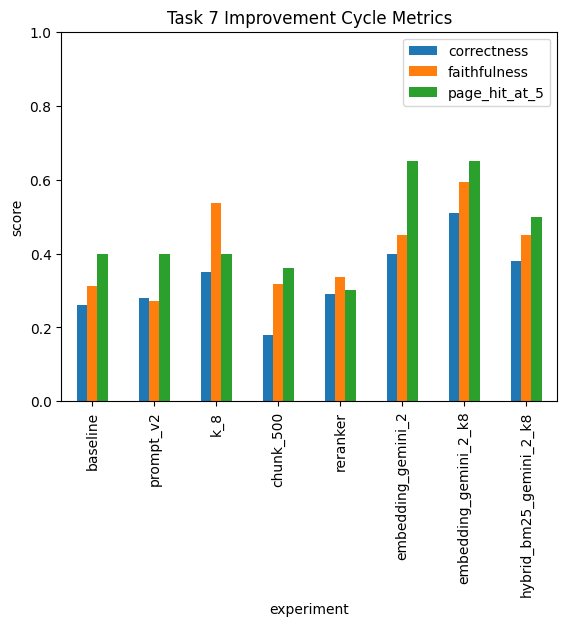

In [ ]:
try:
    import matplotlib.pyplot as plt

    metric_columns = [
        column
        for column in ["correctness", "faithfulness", "page_hit_at_5"]
        if column in task7_results_display_df.columns
    ]
    if (
        task7_results_display_df.empty
        or "experiment" not in task7_results_display_df.columns
        or not metric_columns
    ):
        task7_visualization_output = mo.md("No Task 7 metrics available to plot.")
    else:
        _plot_df = task7_results_display_df[["experiment", *metric_columns]].copy()
        for _column in metric_columns:
            _plot_df[_column] = pd.to_numeric(_plot_df[_column], errors="coerce")
        _ax = _plot_df.set_index("experiment")[metric_columns].plot(kind="bar")
        _ax.set_ylim(0, 1)
        _ax.set_ylabel("score")
        _ax.set_title("Task 7 Improvement Cycle Metrics")
        _ax.legend(loc="best")
        task7_visualization_output = mo.mpl.interactive(_ax.figure)
except Exception as task7_plot_exc:
    task7_visualization_output = mo.md(
        f"Task 7 visualization skipped: `{repr(task7_plot_exc)}`"
    )
task7_visualization_output

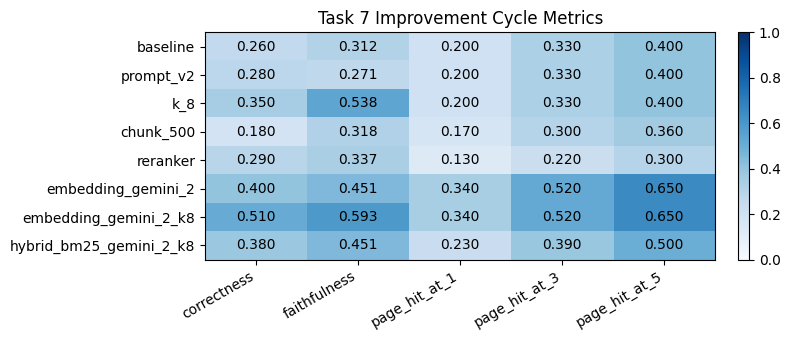

In [ ]:
def make_task7_heatmap_output(task7_results_display_df, mo, pd):
    import matplotlib.pyplot as plt

    metric_columns = [
        column
        for column in [
            "correctness",
            "faithfulness",
            "page_hit_at_1",
            "page_hit_at_3",
            "page_hit_at_5",
        ]
        if column in task7_results_display_df.columns
    ]

    if (
        task7_results_display_df.empty
        or "experiment" not in task7_results_display_df.columns
        or not metric_columns
    ):
        return mo.md("No Task 7 metrics available to plot.")

    heatmap_df = task7_results_display_df[["experiment", *metric_columns]].copy()

    for column in metric_columns:
        heatmap_df[column] = pd.to_numeric(
            heatmap_df[column],
            errors="coerce",
        )

    heatmap_df = heatmap_df.set_index("experiment")[metric_columns]

    fig, ax = plt.subplots(figsize=(8, 3.5))
    image = ax.imshow(
        heatmap_df,
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap="Blues",
    )

    ax.set_xticks(range(len(metric_columns)))
    ax.set_xticklabels(metric_columns, rotation=30, ha="right")
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)

    for row_index, experiment in enumerate(heatmap_df.index):
        for col_index, metric in enumerate(metric_columns):
            value = heatmap_df.loc[experiment, metric]
            if pd.notna(value):
                ax.text(
                    col_index,
                    row_index,
                    f"{value:.3f}",
                    ha="center",
                    va="center",
                    color="black",
                )

    ax.set_title("Task 7 Improvement Cycle Metrics")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()

    return mo.mpl.interactive(fig)


task7_heatmap_output = make_task7_heatmap_output(
    task7_results_display_df=task7_results_display_df,
    mo=mo,
    pd=pd,
)

task7_heatmap_output

In [ ]:
if task7_results_display_df.empty:
    task7_experiment_lines = "No Task 7 experiment results are available yet."
else:
    task7_experiment_lines = "\n".join(
        (
            f"- `{row['experiment']}` hypothesis: {row.get('hypothesis', '')}"
        )
        for row in task7_results_display_df.to_dict("records")
    )
task7_qa_output = mo.md(f"""
### Answers - Task 7

	Q: What is the hypothesis and interpretation for each experiment?

	A: Hypotheses:
{task7_experiment_lines}

	Interpretations:
- `prompt_v2`: Almost no change, made faithfulness worse. Quite possibly could be tuned more, but I don't deem this to be the top spot to improve. 
- `k_8`: Surprisingly good results (Okay, not so surprising given we're just increasing the probability correct chunks entering the context. ); would definitely increase input tokens and increase cost. I haven't tracked it in this assignment - just forgot to be honest. 
- `chunk_500`: Worse results quite possibly because chunk size is not the determinant here. It is already quite small to capture the document part meaning. 
- `reranker`: Quite peculiar, better result with a lower hit rate. 
- `embedding_gemini_2`: As expected, it produced a meaningful improvement in both hit rate and subsequent faithfulness + correctness. 
- `embedding_gemini_2_k8`: Again as expected those improvements proved additive, so they're worth combining. 
- `hybrid_bm25_gemini_2_k8`: Worse results likely because of equally weighting both approaches → Full text search is likely too noisy for it as it doesn't have any metadata or any ontology. Definitely asking for a neurosymbolic approach. 

Q: Where does the pipeline fail most — retrieval, generation, or both? What would you try with one more week?

A: The current pipeline fails most at retrieval. The generator is actually quite conservative, uh which is a surprise given it's not a big model. I would try several approaches:
- Possibly adding a kind of a metadata or frontmatter summary, per document and per document section ideally. 
- Maybe I might put all the documents in a graph so they are connected and we are searching by meaning + hierarchyq as well.
""")
task7_qa_output

### Answers - Task 7

        Q: What is the hypothesis and interpretation for each experiment?

        A: Hypotheses:
- `baseline` hypothesis: Baseline establishes the current retrieval and generation quality before changes.
- `prompt_v2` hypothesis: A stricter prompt should reduce unsupported answers and improve citation discipline.
- `k_8` hypothesis: More chunks should increase the chance that the evidence page reaches the generator.
- `chunk_500` hypothesis: Smaller chunks may retrieve more targeted balance-sheet and table evidence.
- `reranker` hypothesis: A cross-encoder reranker should demote semantically related but unsupported chunks.
- `embedding_gemini_2` hypothesis: Gemini embeddings may improve page-hit by using a stronger external embedding model.
- `embedding_gemini_2_k8` hypothesis: Combining Gemini embeddings with more retrieved chunks may improve answer coverage when relevant evidence is near the top results.
- `hybrid_bm25_gemini_2_k8` hypothesis: Hybrid lexical and semantic retrieval should improve exact company, year, and financial metric matching while preserving semantic recall.

        Interpretations:
- `prompt_v2`: Almost no change, made faithfulness worse. Quite possibly could be tuned more, but I don't deem this to be the top spot to improve. 
- `k_8`: Surprisingly good results (Okay, not so surprising given we're just increasing the probability correct chunks entering the context. ); would definitely increase input tokens and increase cost. I haven't tracked it in this assignment - just forgot to be honest. 
- `chunk_500`: Worse results quite possibly because chunk size is not the determinant here. It is already quite small to capture the document part meaning. 
- `reranker`: Quite peculiar, better result with a lower hit rate. 
- `embedding_gemini_2`: As expected, it produced a meaningful improvement in both hit rate and subsequent faithfulness + correctness. 
- `embedding_gemini_2_k8`: Again as expected those improvements proved additive, so they're worth combining. 
- `hybrid_bm25_gemini_2_k8`: Worse results likely because of equally weighting both approaches → Full text search is likely too noisy for it as it doesn't have any metadata or any ontology. Definitely asking for a neurosymbolic approach. 

Q: Where does the pipeline fail most — retrieval, generation, or both? What would you try with one more week?

A: The current pipeline fails most at retrieval. The generator is actually quite conservative, uh which is a surprise given it's not a big model. I would try several approaches:
- Possibly adding a kind of a metadata or frontmatter summary, per document and per document section ideally. 
- Maybe I might put all the documents in a graph so they are connected and we are searching by meaning + hierarchyq as well.

In [ ]:
baseline_vs_chunk500 = (
    task7_attempt_rows_df[
        task7_attempt_rows_df["experiment"].isin(["prompt_v2", "chunk_500"])
    ]
    .pivot(index="financebench_id", columns="experiment", values="correctness")
    .dropna()
)

disagreement_rate = (
    baseline_vs_chunk500["prompt_v2"]
    != baseline_vs_chunk500["chunk_500"]
).mean()

disagreement_rate

np.float64(0.2)

In [ ]:
bonus_output = mo.md(f"""
## Bonus - Multi-Scale Chunking

Optional extension:
- build FAISS indices for chunk sizes such as 300, 1000, and 2000;
- keep embedding model, splitter type, and overlap policy fixed;
- compare page-hit@5 per question and summarize whether the best chunk size is query-dependent.

Q: If you did the bonus, what does the summary table show? What is the disagreement rate and what does it mean?

A: I actually did chunk-500 sizing. Disagreement rate is {disagreement_rate}. Given lower chunks are hurting both hit rate and correctness - I'd reiterate again that likely they're just losing on big context table or information chunks. I'm not sure overlap would be helpful here, as we could just increase the chunk size?
""")
bonus_output

## Bonus - Multi-Scale Chunking

Optional extension:
- build FAISS indices for chunk sizes such as 300, 1000, and 2000;
- keep embedding model, splitter type, and overlap policy fixed;
- compare page-hit@5 per question and summarize whether the best chunk size is query-dependent.

Q: If you did the bonus, what does the summary table show? What is the disagreement rate and what does it mean?

A: I actually did chunk-500 sizing. Disagreement rate is 0.2. Given lower chunks are hurting both hit rate and correctness - I'd reiterate again that likely they're just losing on big context table or information chunks. I'm not sure overlap would be helpful here, as we could just increase the chunk size?

In [ ]:
all_export_paths = [
    *task1_export_paths,
    *task5_export_paths,
    *task6_export_paths,
    *task7_export_paths,
]
export_path_lines = "\n".join(f"- `{path}`" for path in all_export_paths)
deliverables_output = mo.md(
    f"""
    ## Deliverables

    Generated table paths:

{export_path_lines}

    Final export command:

```bash
uv run marimo export ipynb w2-ai-product/ai-product-2.py -o w2-ai-product/ai-product-2.ipynb --include-outputs -f
```
    """
)
deliverables_output

    ## Deliverables

    Generated table paths:

- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_naive_generation.xlsx`
- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_naive_generation.csv`
- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_run_and_compare.xlsx`
- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_run_and_compare.csv`
- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_evaluation.xlsx`
- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_evaluation.csv`
- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_improvement_cycles.xlsx`
- `/Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/ai-product-2/outputs/assignment2/assignment2_improvement_cycles.csv`

    Final export command:

```bash
uv run marimo export ipynb w2-ai-product/ai-product-2.py -o w2-ai-product/ai-product-2.ipynb --include-outputs -f
```
    